# California Wildfire Prediction Using Machine Learning

> **Note on section numbering:** the 15 numbered sections below follow the notebook's actual run order (Feature Engineering, Section 7, runs before the final Preprocessing step, Section 10, and the Split, Section 8, runs before Imbalance handling, Section 9 - this is intentional, see the rationale in each section). The checklist table in Section 15 uses these same section numbers.

![Model Pipeline](C:\Users\ahmed\Downloads\California_WildFire_Prediction\ML_Pipeline.png)

## 1. Introduction

Wildfires are a major environmental and socioeconomic problem in California.
They can destroy forests, homes, infrastructure, and wildlife habitats.
Early prediction of wildfire occurrence can help emergency services and
decision-makers improve monitoring, preparedness, and resource allocation.

This project develops a machine learning model to predict whether a wildfire
will occur in a specific spatial grid cell during the next 24 hours.

### Problem Definition

The problem is formulated as a binary classification task.

For each location and timestamp T, the model uses environmental conditions
available at time T, such as:

- Temperature
- Dew-point temperature
- Wind speed and direction
- Surface pressure
- Precipitation
- Vegetation indices such as NDVI and EVI
- Elevation
- Land-cover type

The target variable is:

- `fire_next_24h = 1`: a fire is detected in the same grid cell during the next 24 hours.
- `fire_next_24h = 0`: no fire is detected during the next 24 hours.

### Project Objective

The main objective is to build and evaluate machine learning models that can
estimate the probability of wildfire occurrence during the following 24 hours.

The project compares multiple classification algorithms and identifies the
best-performing model using Precision, Recall, F1/F2-score, PR-AUC (average
precision), ROC-AUC and Accuracy. Because fires are rare, **Recall on the fire
class and PR-AUC are the primary metrics**; Accuracy is reported only for
completeness (a model that never predicts fire already scores ~97-98%).

A time-based split is used: 2024 data is used for training (January-October)
and validation (November-December), and 2025 data is used for testing. A
24-hour embargo is applied at each split boundary because the target looks 24
hours ahead. This simulates a real forecasting scenario and prevents future
information from leaking into the training data.

### Note on Scalability

The underlying dataset contains close to **30 million hourly grid-cell
observations**. This is far more than a classical ML pipeline (as opposed to
an LLM) needs, or can practically fit in memory / train on, on a normal
machine. This notebook therefore applies a set of documented, deliberate
size-reduction steps (memory-efficient dtypes, a training sample that keeps
**every fire observation** and undersamples only the no-fire class, and a
stratified sample for validation/test metrics) so the
pipeline stays fast and reproducible **without changing the definition of the
problem** or discarding the natural class imbalance in the evaluation sets.


## 2. Dataset Selection and Data Sources

This project uses a real-world environmental dataset created by integrating
multiple satellite and reanalysis data sources for California during
2024-2025.

The final dataset contains hourly spatial observations and includes more than
10,000 samples and at least 12 predictive features (in practice, close to 30
million rows and 14 raw variables before feature engineering).

### Data Sources

#### ERA5 - Hourly Weather Data

ERA5 is an hourly global atmospheric reanalysis dataset provided by the
Copernicus Climate Change Service.

It provides the following weather variables:

- 2-meter temperature
- 2-meter dew-point temperature
- Surface pressure
- 10-meter eastward wind
- 10-meter northward wind
- Total precipitation

Source: [Copernicus ERA5 hourly data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)

#### NASA FIRMS - Active Fire Detections

NASA FIRMS provides satellite-based active fire and thermal anomaly
detections. It is used to identify the location and acquisition time of
detected fires.

The dataset includes:

- Latitude and longitude
- Acquisition date and time
- Brightness temperature
- Fire Radiative Power (FRP)
- Detection confidence
- Satellite and instrument information

Source: [NASA FIRMS Active Fire Data](https://firms.modaps.eosdis.nasa.gov/active_fire/)

#### MODIS MOD13Q1 - Vegetation Indices

MOD13Q1 is a MODIS vegetation-index product with a 16-day temporal
composite and 250-meter spatial resolution.

The project uses:

- NDVI
- EVI
- Pixel Reliability
- VI Quality

Source: [MODIS Vegetation Index Product Guide](https://lpdaac.usgs.gov/documents/103/MOD13_User_Guide_V6.pdf)

#### SRTM - Elevation Data

SRTM provides digital elevation information derived from radar observations.
The project uses SRTM 1 Arc-Second tiles to represent terrain elevation.

Source: [SRTM Collection User Guide](https://lpdaac.usgs.gov/documents/179/SRTM_User_Guide_V3.pdf)

#### MODIS MCD12Q1 - Land Cover

MCD12Q1 provides annual global land-cover classification data. The
land-cover layer is used to describe the surface type at each location.

Examples of land-cover classes include:

- Forest
- Grassland
- Shrubland
- Cropland
- Urban areas
- Barren land

Source: [MCD12Q1 Land Cover User Guide](https://lpdaac.usgs.gov/documents/1409/MCD12_User_Guide_V61.pdf)

### Final Integrated Dataset

All source datasets were spatially aligned to the ERA5 grid and temporally
aligned for the period 2024-2025. MODIS observations were matched using the
most recent observation available at or before time T. The target variable
`fire_next_24h` indicates whether a fire was detected in the same grid cell
during the following 24 hours.

The final integrated file is: `master_dataset_2024_2025.nc`


## 3. Loading and Inspecting the Dataset

In [1]:
import gc
import time

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

# =====================================================================
# Central configuration -- every tunable choice of the pipeline lives here
# =====================================================================
TARGET = "fire_next_24h"

# --- Chronological split: 2024 -> train + validation, 2025 -> test -----------
VAL_START = pd.Timestamp("2024-11-01")
TEST_START = pd.Timestamp("2025-01-01")
# The label at time T looks 24 h ahead, so rows within 24 h of a split boundary
# would share label information with the next period. They are dropped (embargo).
EMBARGO = pd.Timedelta(hours=24)

# --- Extra features -----------------------------------------------------------
USE_HISTORY_FEATURES = True       # antecedent rain / dryness (causal rolling windows)
MAX_HISTORY_HOURS = 720           # longest rolling window (30 days) = warm-up period
USE_RECENT_FIRE_FEATURE = False   # adds "was there a fire in this cell during the last 24 h?"
                                  # OFF by default: it turns ignition-risk prediction into
                                  # persistence forecasting (see Section 7 for the discussion).

# --- Class-imbalance handling (training data only) -----------------------------
NEG_TO_POS_RATIO = 5              # keep ALL fire rows and up to 5 no-fire rows per fire row
MAX_TRAIN_ROWS = 1_200_000        # size cap; only the no-fire class is shrunk to respect it
MAX_EVAL_ROWS = 400_000           # stratified sample size for validation / test metrics

# --- Decision rule (how the probability score becomes "fire" / "no fire") ------
THRESHOLD_STRATEGY = "fbeta"      # "fbeta": maximise F-beta | "target_recall": highest precision with recall >= TARGET_RECALL
BETA = 2.0                        # beta > 1 weights Recall more than Precision (F2)
TARGET_RECALL = 0.80

# --- Feature selection / tuning ------------------------------------------------
MIN_RELATIVE_GAIN = 0.01          # a feature group must improve validation PR-AUC by >= 1 % to be kept
N_TUNING_CANDIDATES = 15          # random-search budget (the default configuration is always evaluated too)
REFIT_ON_TRAIN_VAL = True         # refit on train + validation (same sampling recipe) before the final test

### Load data

To ensure this notebook is fully reproducible and easy to run for anyone
without requiring manual downloads, the dataset is hosted on Google Drive.
We use `gdown` to fetch the data directly, and `xarray` to open the
downloaded NetCDF (`.nc`) file into an `xarray.Dataset`.

In [2]:
import sys

!{sys.executable} -m pip install --quiet gdown netCDF4



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import gdown

file_id = "1LzCjsxT9TaPnDIQ_yW_wz8wqPrwRcFte"
output = "master_dataset_2024_2025.nc"

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

data = xr.open_dataset(output)

# The raw file carries a couple of unused ERA5 metadata dims ("number", "expver")
# that add columns but no signal, and every numeric variable loads as float64.
# Dropping the former and downcasting the latter to float32 roughly halves the
# memory needed for the full-dataset -> DataFrame conversion two cells down,
# which is what actually exhausts RAM on the ~29M-row dataset.
data = data.drop_vars(["number", "expver"], errors="ignore")
float64_vars = [v for v in data.data_vars if data[v].dtype == "float64"]
if float64_vars:
    data[float64_vars] = data[float64_vars].astype("float32")

data


<xarray.Dataset> Size: 1GB
Dimensions:            (valid_time: 17544, latitude: 39, longitude: 43)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 140kB 2024-01-01 ... 2025-...
  * latitude           (latitude) float64 312B 42.0 41.75 41.5 ... 32.75 32.5
  * longitude          (longitude) float64 344B -124.5 -124.2 ... -114.2 -114.0
Data variables: (12/14)
    u10                (valid_time, latitude, longitude) float32 118MB ...
    v10                (valid_time, latitude, longitude) float32 118MB ...
    d2m                (valid_time, latitude, longitude) float32 118MB ...
    t2m                (valid_time, latitude, longitude) float32 118MB ...
    sp                 (valid_time, latitude, longitude) float32 118MB ...
    tp                 (valid_time, latitude, longitude) float32 118MB ...
    ...                 ...
    land_cover         (latitude, longitude) float32 7kB ...
    elevation          (latitude, longitude) float32 7kB ...
    evi                (valid_time, latitude, longitude) float32 118MB ...
    ndvi               (valid_time, latitude, longitude) float32 118MB ...
    pixel_reliability  (valid_time, latitude, longitude) float32 118MB ...
    vi_quality         (valid_time, latitude, longitude) float32 118MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-16T21:46 GRIB to CDM+CF via cfgrib-0.9.1...
    target_definition:       any FIRMS detection in (T, T+24h] on nearest ERA...
    firms_rows_used:         243203
    dataset_definition:      Hourly ERA5 predictors plus leakage-safe FIRMS n...
    modis_join:              Most recent MODIS observation at or before valid...

In [4]:
print(data.sizes)



Frozen({'valid_time': 17544, 'latitude': 39, 'longitude': 43})


In [5]:
print(list(data.data_vars))



['u10', 'v10', 'd2m', 't2m', 'sp', 'tp', 'fire_now', 'fire_next_24h', 'land_cover', 'elevation', 'evi', 'ndvi', 'pixel_reliability', 'vi_quality']


### Antecedent (history) weather features

Fuel dryness depends on the weather of the previous days and weeks, not only on
the current hour. Rolling statistics of rain, vapour-pressure deficit (VPD),
temperature and wind are therefore computed here, **on the complete regular
(time x latitude x longitude) grid, before any row is dropped**, so that a
"168-hour" window really covers 168 consecutive hours.

All windows are **causal**: a window ends at time T and never looks forward, so
no future information is used. Cumulative sums are computed in `float64`
(a `float32` cumulative sum of ~290 K temperatures would lose all precision).
The first `MAX_HISTORY_HOURS` of the record have truncated windows and are
excluded from training in Section 8.

These features need the recent weather history at prediction time (see the
deployment note in Section 14). Set `USE_HISTORY_FEATURES = False` in the
configuration cell to switch them off.

In [6]:
# The rolling windows are row-based, so the time axis must be a strictly regular hourly axis
step_hours = np.diff(data["valid_time"].values) / np.timedelta64(1, "h")
if not np.all(step_hours == 1):
    raise ValueError("valid_time is not a strictly regular hourly axis - rolling windows would be wrong.")
RECORD_START = pd.Timestamp(data["valid_time"].values.min())


def saturation_vapor_pressure_kpa(t_celsius):
    """Tetens formula (kPa). Works on numpy arrays, pandas Series and xarray DataArrays."""
    return 0.6108 * np.exp(17.27 * t_celsius / (t_celsius + 237.3))


def causal_rolling_sum(da, hours, dim="valid_time"):
    """Sum over the last `hours` steps INCLUDING the current one (never looks forward)."""
    cs = da.astype("float64").fillna(0.0).cumsum(dim)
    return (cs - cs.shift({dim: hours}, fill_value=0.0)).astype("float32")


def causal_rolling_mean(da, hours, dim="valid_time"):
    """Mean over the last `hours` steps INCLUDING the current one (partial window at the record start)."""
    n_steps = np.minimum(np.arange(1, da.sizes[dim] + 1), hours)
    n_steps = xr.DataArray(n_steps, dims=dim, coords={dim: da[dim].values})
    cs = da.astype("float64").fillna(0.0).cumsum(dim)
    return ((cs - cs.shift({dim: hours}, fill_value=0.0)) / n_steps).astype("float32")


HISTORY_FEATURES = []
RECENT_FIRE_FEATURES = []

if USE_HISTORY_FEATURES:
    t_c = data["t2m"] - 273.15
    td_c = data["d2m"] - 273.15
    vpd_grid = (saturation_vapor_pressure_kpa(t_c) - saturation_vapor_pressure_kpa(td_c)).clip(min=0)
    wind_grid = np.sqrt(data["u10"] ** 2 + data["v10"] ** 2)

    history_definitions = {
        "tp_sum_24h": causal_rolling_sum(data["tp"], 24),        # rain in the last 24 h
        "tp_sum_7d": causal_rolling_sum(data["tp"], 168),        # rain in the last 7 days
        "tp_sum_30d": causal_rolling_sum(data["tp"], 720),       # rain in the last 30 days
        "vpd_mean_24h": causal_rolling_mean(vpd_grid, 24),       # mean atmospheric dryness, last 24 h
        "vpd_mean_7d": causal_rolling_mean(vpd_grid, 168),       # ... last 7 days
        "t2m_mean_7d": causal_rolling_mean(t_c, 168),            # mean temperature (deg C), last 7 days
        "wind_mean_24h": causal_rolling_mean(wind_grid, 24),     # mean wind speed, last 24 h
    }
    for name, da in history_definitions.items():
        data[name] = da
    HISTORY_FEATURES = list(history_definitions)
    del t_c, td_c, vpd_grid, wind_grid, history_definitions
    gc.collect()

if USE_RECENT_FIRE_FEATURE:
    # fire_next_24h at time T-24h = "fire detected during the 24 h that ended at T" -> known at time T
    data["fire_prev_24h"] = data[TARGET].fillna(0).shift(valid_time=24, fill_value=0).astype("float32")
    RECENT_FIRE_FEATURES = ["fire_prev_24h"]

print("Record starts at:", RECORD_START)
print("History features added:", HISTORY_FEATURES)
print("Recent-fire features added:", RECENT_FIRE_FEATURES)

Record starts at: 2024-01-01 00:00:00
History features added: ['tp_sum_24h', 'tp_sum_7d', 'tp_sum_30d', 'vpd_mean_24h', 'vpd_mean_7d', 't2m_mean_7d', 'wind_mean_24h']
Recent-fire features added: []


In [7]:
df = data.to_dataframe().reset_index()
df.head()



,valid_time,latitude,longitude,u10,v10,d2m,t2m,sp,tp,fire_now,...,ndvi,pixel_reliability,vi_quality,tp_sum_24h,tp_sum_7d,tp_sum_30d,vpd_mean_24h,vpd_mean_7d,t2m_mean_7d,wind_mean_24h
0,2024-01-01,42.0,-124.50,-0.613495,-1.720047,280.911621,284.971924,101740.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.330703,0.330703,11.821930,1.826181
1,2024-01-01,42.0,-124.25,-0.005096,-1.137039,281.495605,284.141846,99704.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.213719,0.213719,10.991852,1.137051
2,2024-01-01,42.0,-124.00,0.156036,-0.806961,278.206543,282.803955,95526.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.324017,0.324017,9.653961,0.821908
3,2024-01-01,42.0,-123.75,0.025177,-0.675125,275.140137,281.585205,91860.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.399841,0.399841,8.435211,0.675594
4,2024-01-01,42.0,-123.50,-0.412323,-0.712234,274.366699,280.874268,90125.5625,0.0,0,...,-130.0,2.0,18717.0,0.0,0.0,0.0,0.385738,0.385738,7.724274,0.822975


In [8]:
print("Data shape:", df.shape)


Data shape: (29421288, 24)


In [9]:
df.describe(include="all").T


,count,mean,min,25%,50%,75%,max,std
valid_time,29421288,2024-12-31 11:30:00,2024-01-01 00:00:00,2024-07-01 17:45:00,2024-12-31 11:30:00,2025-07-02 05:15:00,2025-12-31 23:00:00,NaN
latitude,29421288.0,37.25,32.5,34.75,37.25,39.75,42.0,2.813657
longitude,29421288.0,-119.25,-124.5,-122.0,-119.25,-116.5,-114.0,3.102418
u10,29421288.0,1.261789,-18.228333,-0.352753,0.966095,2.527328,19.208282,2.33856
v10,29421288.0,-0.872057,-18.792053,-2.116608,-0.331284,1.087509,21.049438,3.452852
d2m,29421288.0,276.744019,232.478455,270.755127,277.474609,283.655273,301.213135,8.137503
t2m,29421288.0,287.673706,243.748215,282.4646,287.339844,292.342773,323.810303,9.344931
sp,29421288.0,91945.640625,69965.5,83812.3125,92551.9375,101032.375,104066.5,8443.708984
tp,29421288.0,0.000053,0.0,0.0,0.0,0.0,0.016606,0.000297
fire_now,29421288.0,0.001729,0.0,0.0,0.0,0.0,1.0,0.041544


In [10]:
df.isnull().sum()


valid_time                  0
latitude                    0
longitude                   0
u10                         0
v10                         0
d2m                         0
t2m                         0
sp                          0
tp                          0
fire_now                    0
fire_next_24h               0
land_cover           17473824
elevation             4421088
evi                  17636640
ndvi                 17637360
pixel_reliability    17637360
vi_quality           17570784
tp_sum_24h                  0
tp_sum_7d                   0
tp_sum_30d                  0
vpd_mean_24h                0
vpd_mean_7d                 0
t2m_mean_7d                 0
wind_mean_24h               0
dtype: int64

### Dataset Understanding

The dataset contains hourly spatio-temporal observations over California.
Each row represents a spatial grid cell at a specific timestamp, with
environmental predictors and a binary wildfire target, `fire_next_24h`
(1 = a fire was detected in the same grid cell during the following 24
hours, 0 = it was not). This confirms the problem is **binary
classification**, as stated in the Introduction.

In [11]:
for name, variable in data.variables.items():
    print(
        f"{name:25s} | "
        f"dtype={variable.dtype} | "
        f"shape={variable.shape}"
    )



u10                       | dtype=float32 | shape=(17544, 39, 43)
v10                       | dtype=float32 | shape=(17544, 39, 43)
d2m                       | dtype=float32 | shape=(17544, 39, 43)
t2m                       | dtype=float32 | shape=(17544, 39, 43)
sp                        | dtype=float32 | shape=(17544, 39, 43)
tp                        | dtype=float32 | shape=(17544, 39, 43)
fire_now                  | dtype=uint8 | shape=(17544, 39, 43)
fire_next_24h             | dtype=uint8 | shape=(17544, 39, 43)
land_cover                | dtype=float32 | shape=(39, 43)
elevation                 | dtype=float32 | shape=(39, 43)
evi                       | dtype=float32 | shape=(17544, 39, 43)
ndvi                      | dtype=float32 | shape=(17544, 39, 43)
pixel_reliability         | dtype=float32 | shape=(17544, 39, 43)
vi_quality                | dtype=float32 | shape=(17544, 39, 43)
valid_time                | dtype=datetime64[ns] | shape=(17544,)
latitude                  | 

In [12]:
# Define target and candidate (raw) predictors
target = TARGET

candidate_features = [
    "u10", "v10", "d2m", "t2m",
    "sp", "tp",
    "land_cover", "elevation",
    "evi", "ndvi",
    "pixel_reliability", "vi_quality"
]

print("Target:", target)
print("Number of candidate features:", len(candidate_features))
print(candidate_features)


Target: fire_next_24h
Number of candidate features: 12
['u10', 'v10', 'd2m', 't2m', 'sp', 'tp', 'land_cover', 'elevation', 'evi', 'ndvi', 'pixel_reliability', 'vi_quality']


In [13]:
# Inspect the target without converting the entire dataset to a DataFrame
target_values = data[target].values

print("Target unique values:", np.unique(target_values))
print("Target shape:", target_values.shape)
print("Positive observations:", np.sum(target_values == 1))
print("Negative observations:", np.sum(target_values == 0))


Target unique values: [0 1]
Target shape: (17544, 39, 43)
Positive observations: 727703
Negative observations: 28693585


In [14]:
# Convert a small sample for initial inspection
sample_df = data.isel(valid_time=slice(0, 500)).to_dataframe().reset_index()
print("Sample shape:", sample_df.shape)
sample_df.head()


Sample shape: (838500, 24)


,valid_time,latitude,longitude,u10,v10,d2m,t2m,sp,tp,fire_now,...,ndvi,pixel_reliability,vi_quality,tp_sum_24h,tp_sum_7d,tp_sum_30d,vpd_mean_24h,vpd_mean_7d,t2m_mean_7d,wind_mean_24h
0,2024-01-01,42.0,-124.50,-0.613495,-1.720047,280.911621,284.971924,101740.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.330703,0.330703,11.821930,1.826181
1,2024-01-01,42.0,-124.25,-0.005096,-1.137039,281.495605,284.141846,99704.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.213719,0.213719,10.991852,1.137051
2,2024-01-01,42.0,-124.00,0.156036,-0.806961,278.206543,282.803955,95526.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.324017,0.324017,9.653961,0.821908
3,2024-01-01,42.0,-123.75,0.025177,-0.675125,275.140137,281.585205,91860.5625,0.0,0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.399841,0.399841,8.435211,0.675594
4,2024-01-01,42.0,-123.50,-0.412323,-0.712234,274.366699,280.874268,90125.5625,0.0,0,...,-130.0,2.0,18717.0,0.0,0.0,0.0,0.385738,0.385738,7.724274,0.822975


## 4. Data Quality Analysis

In [15]:
# Efficient missing-value analysis using xarray
missing_report = {}

for feature in candidate_features + [target]:
    values = data[feature].values
    missing_count = np.isnan(values).sum()
    total_count = values.size

    missing_report[feature] = {
        "missing_count": int(missing_count),
        "missing_percentage": float(missing_count / total_count * 100)
    }

missing_df = pd.DataFrame(missing_report).T
missing_df.sort_values("missing_percentage", ascending=False)


,missing_count,missing_percentage
pixel_reliability,17637360.0,59.947613
ndvi,17637360.0,59.947613
evi,17636640.0,59.945166
vi_quality,17570784.0,59.721328
land_cover,996.0,59.391771
elevation,252.0,15.026834
sp,0.0,0.000000
d2m,0.0,0.000000
v10,0.0,0.000000
u10,0.0,0.000000


In [16]:
# Check whether the dataset has the expected complete spatio-temporal grid
expected_rows = data.sizes["valid_time"] * data.sizes["latitude"] * data.sizes["longitude"]
actual_rows = data[target].size

print("Expected spatio-temporal observations:", expected_rows)
print("Actual observations:", actual_rows)
print("Grid is complete:", expected_rows == actual_rows)


Expected spatio-temporal observations: 29421288
Actual observations: 29421288
Grid is complete: True


In [17]:
dtype_report = pd.DataFrame({
    "feature": list(data.data_vars),
    "dtype": [str(data[var].dtype) for var in data.data_vars]
})
dtype_report


,feature,dtype
0,u10,float32
1,v10,float32
2,d2m,float32
3,t2m,float32
4,sp,float32
5,tp,float32
6,fire_now,uint8
7,fire_next_24h,uint8
8,land_cover,float32
9,elevation,float32


In [18]:
# Check whether any feature has only one unique value (zero variance -> useless)
constant_report = []
for feature in candidate_features:
    values = data[feature].values
    values = values[np.isfinite(values)]
    constant_report.append({
        "feature": feature,
        "unique_values": len(np.unique(values)),
        "is_constant": len(np.unique(values)) <= 1
    })

constant_df = pd.DataFrame(constant_report)
constant_df


,feature,unique_values,is_constant
0,u10,1093773,False
1,v10,1493701,False
2,d2m,1277022,False
3,t2m,604261,False
4,sp,509153,False
5,tp,15536,False
6,land_cover,13,False
7,elevation,956,False
8,evi,5789,False
9,ndvi,8725,False


In [19]:
# Check the cardinality (number of unique values) of each feature
cardinality_report = []
for feature in candidate_features:
    values = data[feature].values
    values = values[np.isfinite(values)]
    cardinality_report.append({"feature": feature, "unique_values": len(np.unique(values))})

cardinality_df = pd.DataFrame(cardinality_report)
cardinality_df.sort_values("unique_values")


,feature,unique_values
10,pixel_reliability,4
6,land_cover,13
11,vi_quality,243
7,elevation,956
8,evi,5789
9,ndvi,8725
5,tp,15536
4,sp,509153
3,t2m,604261
0,u10,1093773


In [20]:
# Target class balance
positive_count = np.sum(target_values == 1)
negative_count = np.sum(target_values == 0)
total_count = positive_count + negative_count

class_balance = pd.DataFrame({
    "class": [0, 1],
    "count": [negative_count, positive_count],
    "percentage": [negative_count / total_count * 100, positive_count / total_count * 100]
})
class_balance


,class,count,percentage
0,0,28693585,97.526611
1,1,727703,2.473389


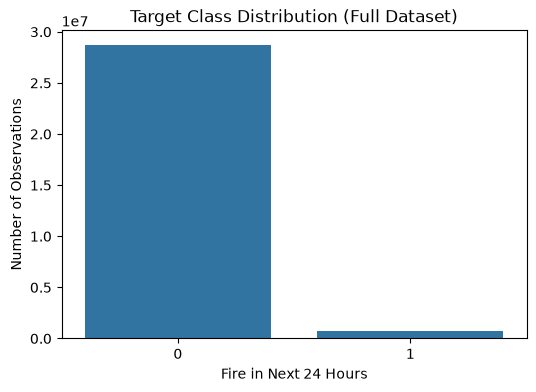

   class     count  percentage
0      0  28693585   97.526611
1      1    727703    2.473389


In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(data=class_balance, x="class", y="count")
plt.title("Target Class Distribution (Full Dataset)")
plt.xlabel("Fire in Next 24 Hours")
plt.ylabel("Number of Observations")
plt.show()

print(class_balance)


**Observation:** the target is heavily imbalanced (roughly 97-98% "no
fire" vs. 2-3% "fire"; exact numbers in the table above). This is handled
later, only on the training set, in section 9 — the validation and test sets
keep the real ratio. Because of this imbalance, PR-AUC and Recall on the fire
class are used as the main metrics instead of Accuracy.

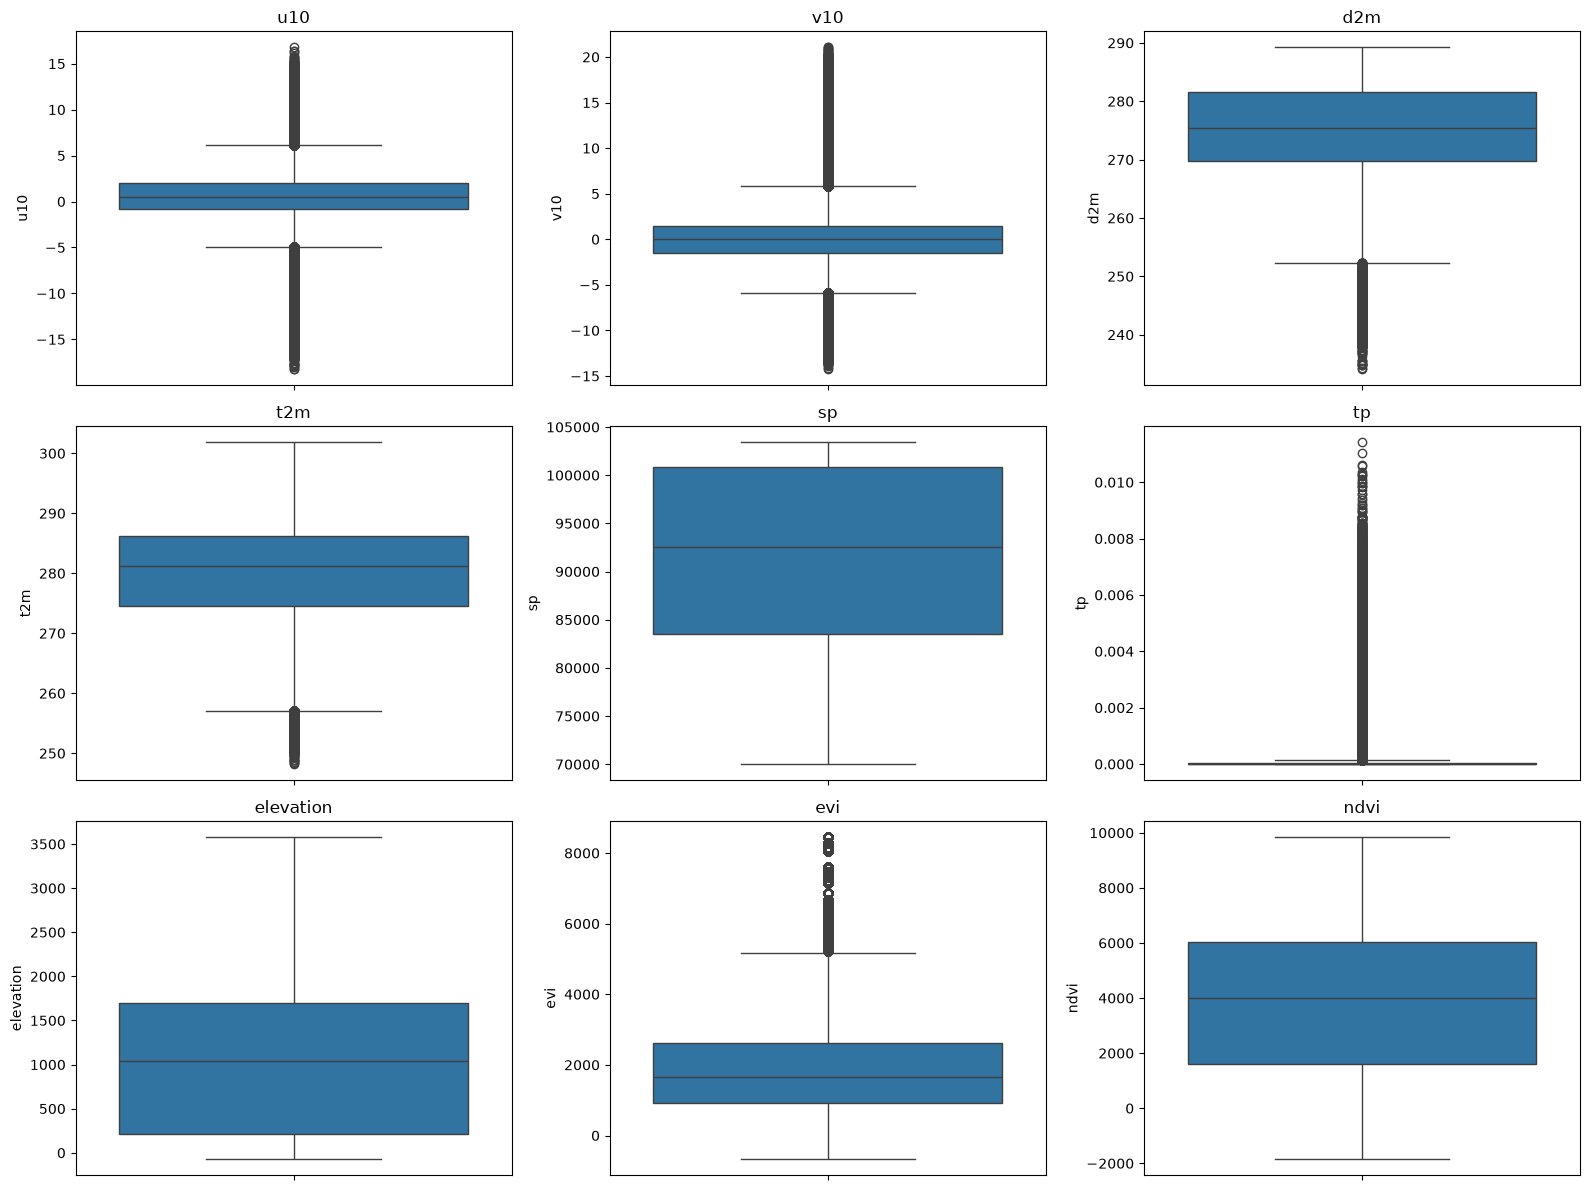

In [22]:
# Quick outlier scan on a small sample of raw values (before cleaning)
eda_sample = data.isel(valid_time=slice(0, 1000)).to_dataframe().reset_index()

numeric_features_eda = ["u10", "v10", "d2m", "t2m", "sp", "tp", "elevation", "evi", "ndvi"]

plt.figure(figsize=(16, 12))
for i, feature in enumerate(numeric_features_eda, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=eda_sample, y=feature)
    plt.title(feature)
plt.tight_layout()
plt.show()


## 5. Data Cleaning, Outlier Treatment and Feature Preparation

This section builds `df_clean` **once**, in order, and reuses it for every
later step (EDA, splitting, modeling).

Steps:
1. Remove technical metadata columns and duplicate spatio-temporal rows.
2. Keep only spatial grid cells that have valid static features at least once.
3. Fill short gaps in the 16-day MODIS vegetation-index composites (past values only).
4. Drop rows still missing core predictors.
5. Treat outliers (see rationale below; bounds are learned on the training period only).
6. Downcast dtypes to reduce memory.
7. Derive the first engineered features needed for EDA (units, wind speed, dryness indicators).

In [23]:
# Define spatial features used to validate each (lat, lon) grid cell
spatial_features = ["land_cover", "elevation", "evi", "ndvi", "pixel_reliability", "vi_quality"]

valid_spatial_cells = (
    df.groupby(["latitude", "longitude"])[spatial_features]
    .first()
    .notnull()
    .all(axis=1)
)

# Create the single cleaned working copy of the dataset
df_clean = df.copy()

# Remove technical metadata columns
df_clean = df_clean.drop(columns=["number", "expver"], errors="ignore")

# Remove duplicate spatial-temporal observations
df_clean = df_clean.drop_duplicates(subset=["latitude", "longitude", "valid_time"])

# Keep only valid spatial cells
df_clean = (
    df_clean.set_index(["latitude", "longitude"])
    .loc[valid_spatial_cells[valid_spatial_cells].index]
    .reset_index()
)

# Sort by location and time (needed for the forward-fill step below)
df_clean = df_clean.sort_values(["latitude", "longitude", "valid_time"]).copy()

# valid_time is used throughout the rest of the notebook, so make sure
# it is a proper datetime column, done once, here
df_clean["valid_time"] = pd.to_datetime(df_clean["valid_time"])

print("df_clean shape:", df_clean.shape)

# The raw DataFrame is no longer needed - free the memory
del df
gc.collect()


df_clean shape: (11859744, 24)


25766

In [24]:
# Fill short gaps in the MODIS vegetation-index composites (16-day product)
# using the last valid observation per grid cell (no leakage from the future)
modis_features = ["evi", "ndvi", "pixel_reliability", "vi_quality"]

df_clean[modis_features] = (
    df_clean.groupby(["latitude", "longitude"])[modis_features]
    .ffill(limit=400)
)

print("Remaining missing values per MODIS feature:")
print(df_clean[modis_features].isnull().sum())


Remaining missing values per MODIS feature:
evi                  57208
ndvi                 58312
pixel_reliability    58312
vi_quality           18160
dtype: int64


In [25]:
# Drop rows that still have missing values in the core (raw) predictors or target
features = candidate_features
df_clean = df_clean.dropna(subset=features + [target]).copy()

print("Shape after dropping remaining missing values:", df_clean.shape)
print("Remaining missing values:", df_clean[features + [target]].isnull().sum().sum())


Shape after dropping remaining missing values: (11801432, 24)
Remaining missing values: 0


### Outlier Treatment

The boxplots above only *detect* outliers. For this dataset, the "outliers" in
variables like wind speed, temperature, dew point and precipitation are largely
genuine fire-weather extremes (hot, dry, windy conditions) — exactly the signal
a wildfire model needs to learn from. Aggressively removing or IQR-clipping
every statistical outlier would strip out the rare, high-risk conditions the
target is trying to predict, and would bias the model toward "normal weather =
no fire".

Instead, a **light winsorization** is applied: each continuous weather variable
is capped at its 0.1st and 99.9th percentiles. This only affects values far
enough out to plausibly be sensor/reanalysis artifacts, while leaving the
genuine fire-weather tail intact. The percentile bounds are computed **on the
training period only** and then applied to every period, so no information from
the validation or test period influences preprocessing. `land_cover`,
`evi`/`ndvi` (already quality-flagged via `pixel_reliability` and `vi_quality`)
and the target are left untouched.

In [26]:
# Light winsorization: cap extreme values at the 0.1 / 99.9 percentiles instead of
# removing rows, so genuine fire-weather extremes are preserved.
# The bounds are learned on the TRAINING period only (no test/validation leakage).
outlier_treated_columns = ["u10", "v10", "d2m", "t2m", "sp", "tp"]
bounds_rows = df_clean["valid_time"] < (VAL_START - EMBARGO)
clip_bounds = {}

for col in outlier_treated_columns:
    lower = float(df_clean.loc[bounds_rows, col].quantile(0.001))
    upper = float(df_clean.loc[bounds_rows, col].quantile(0.999))
    clip_bounds[col] = (lower, upper)

    n_clipped = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f"{col:6s} | bounds=({lower:.4g}, {upper:.4g}) | rows clipped={n_clipped}")

del bounds_rows

u10    | bounds=(-5.14, 8.305) | rows clipped=22807
v10    | bounds=(-6.942, 7.403) | rows clipped=28849
d2m    | bounds=(251.8, 292.8) | rows clipped=41209
t2m    | bounds=(262, 317.7) | rows clipped=23077
sp     | bounds=(7.18e+04, 1.023e+05) | rows clipped=34525
tp     | bounds=(0, 0.003897) | rows clipped=22237


### Memory Optimization

The cleaned dataset is still very large (millions of rows). Before any more
feature engineering, numeric columns are downcast from `float64` to
`float32`, and `land_cover` is converted to a `category` dtype. This does
not lose meaningful precision for this data, and reduces memory for every
step that follows (feature engineering, EDA sampling, splitting, training).

In [27]:
# Downcast numeric columns to float32 and land_cover to category
before_mb = df_clean.memory_usage(deep=True).sum() / 1024**2

float_cols = df_clean.select_dtypes(include=["float64"]).columns
df_clean[float_cols] = df_clean[float_cols].astype("float32")
df_clean["land_cover"] = df_clean["land_cover"].astype("category")
# The target is a 0/1 label: int8 saves memory and gives sklearn clean integer class labels
df_clean[target] = df_clean[target].astype("int8")

after_mb = df_clean.memory_usage(deep=True).sum() / 1024**2

print(f"Memory usage before: {before_mb:,.1f} MB")
print(f"Memory usage after:  {after_mb:,.1f} MB")


Memory usage before: 1,238.0 MB
Memory usage after:  1,114.2 MB


In [28]:
df_clean["t2m_celsius"] = df_clean["t2m"] - 273.15
df_clean["d2m_celsius"] = df_clean["d2m"] - 273.15

# Apply the MODIS scale factor to get scientific NDVI/EVI values
df_clean["ndvi_scaled"] = df_clean["ndvi"] * 0.0001
df_clean["evi_scaled"] = df_clean["evi"] * 0.0001

df_clean[["ndvi_scaled", "evi_scaled"]].describe().T


,count,mean,std,min,25%,50%,75%,max
ndvi_scaled,11801432.0,0.399745,0.247429,-0.1953,0.1726,0.3734,0.6110,0.9914
evi_scaled,11801432.0,0.211832,0.136372,-0.1419,0.1040,0.1854,0.2944,0.9760


In [29]:
df_clean["wind_speed"] = np.sqrt(df_clean["u10"] ** 2 + df_clean["v10"] ** 2)

# Temperature-dew point spread (atmospheric dryness indicator)
df_clean["temp_dewpoint_spread"] = df_clean["t2m_celsius"] - df_clean["d2m_celsius"]

# Relative humidity and vapour-pressure deficit (VPD): the standard fire-weather
# dryness indicators, derived from temperature and dew point (Tetens formula).
# Very low humidity / high VPD dries fuel quickly and is strongly linked to fire spread.
es_air = saturation_vapor_pressure_kpa(df_clean["t2m_celsius"])
es_dew = saturation_vapor_pressure_kpa(df_clean["d2m_celsius"])
df_clean["rel_humidity"] = (100.0 * es_dew / es_air).clip(0, 100).astype("float32")
df_clean["vpd"] = (es_air - es_dew).clip(lower=0).astype("float32")
del es_air, es_dew

df_clean[["wind_speed", "temp_dewpoint_spread", "rel_humidity", "vpd"]].describe().T

,count,mean,std,min,25%,50%,75%,max
wind_speed,11801432.0,2.168603,1.385890,0.000782,1.206615,1.859585,2.776116,11.126086
temp_dewpoint_spread,11801432.0,12.128356,9.797481,-0.002747,3.949219,9.553604,18.333801,59.796448
rel_humidity,11801432.0,52.820389,26.181541,1.988165,29.765647,52.490889,76.243088,100.000000
vpd,11801432.0,1.244979,1.371525,0.000000,0.260016,0.734632,1.748027,9.198647


## 6. Exploratory Data Analysis (EDA)

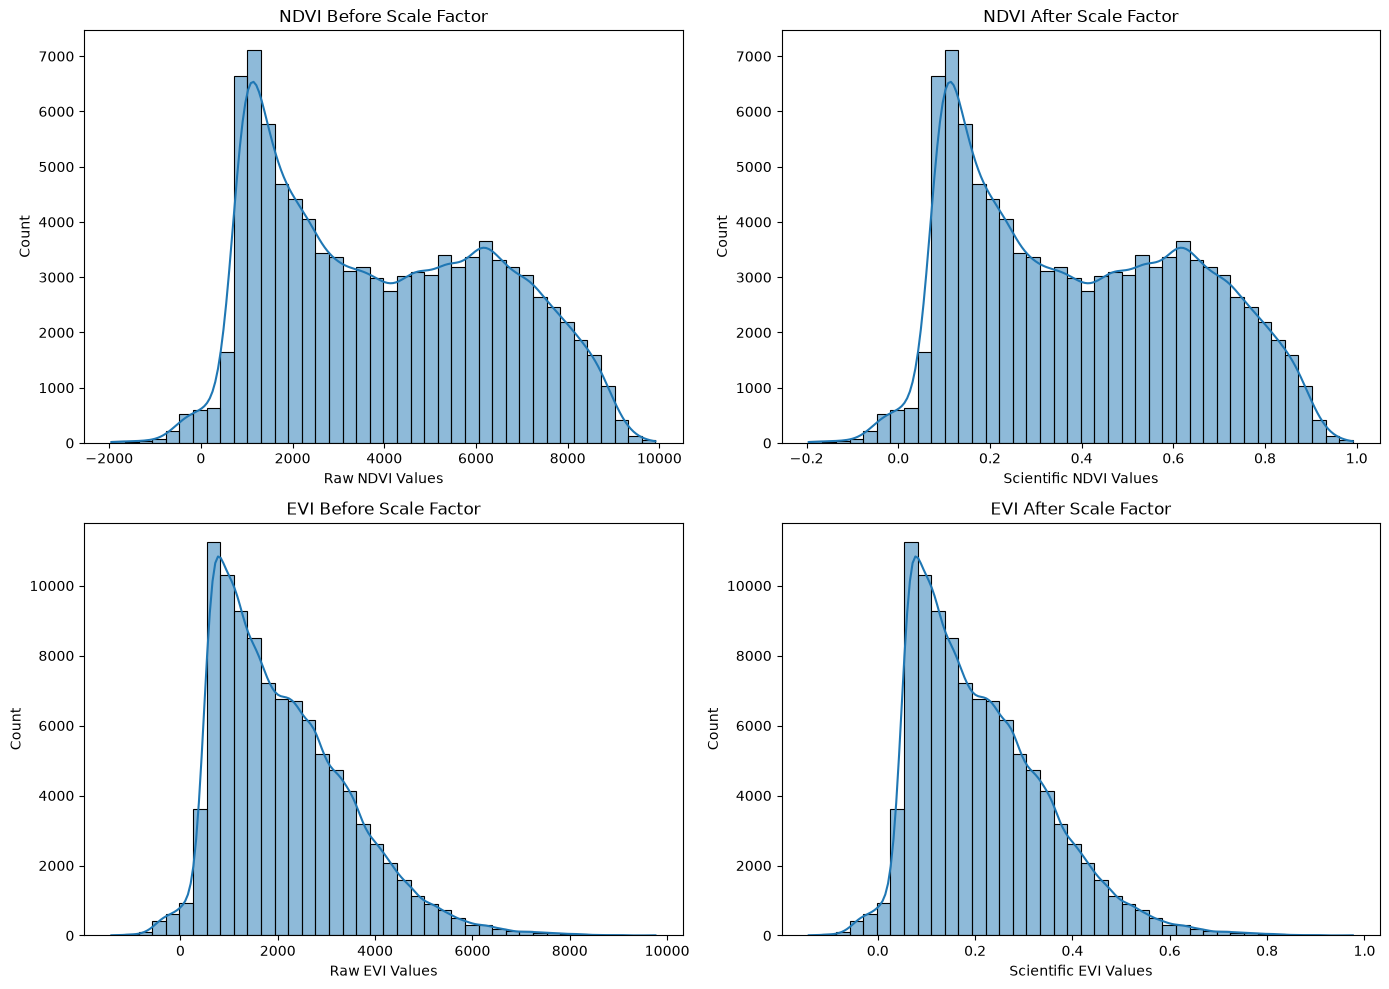

In [30]:
# Sample rows for efficient visualization (plotting on millions of rows
# is slow and not necessary to see the distribution shape)
plot_sample = df_clean.sample(min(100_000, len(df_clean)), random_state=RANDOM_STATE)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(plot_sample["ndvi"], bins=40, kde=True)
plt.title("NDVI Before Scale Factor")
plt.xlabel("Raw NDVI Values")

plt.subplot(2, 2, 2)
sns.histplot(plot_sample["ndvi_scaled"], bins=40, kde=True)
plt.title("NDVI After Scale Factor")
plt.xlabel("Scientific NDVI Values")

plt.subplot(2, 2, 3)
sns.histplot(plot_sample["evi"], bins=40, kde=True)
plt.title("EVI Before Scale Factor")
plt.xlabel("Raw EVI Values")

plt.subplot(2, 2, 4)
sns.histplot(plot_sample["evi_scaled"], bins=40, kde=True)
plt.title("EVI After Scale Factor")
plt.xlabel("Scientific EVI Values")

plt.tight_layout()
plt.show()


### Feature Distributions by Wildfire Target

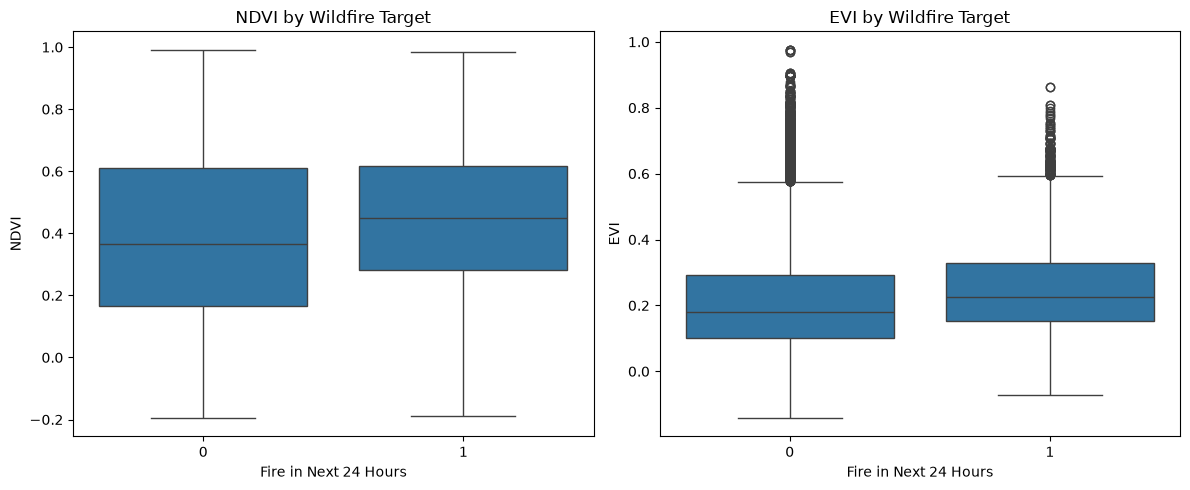

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=plot_sample, x=target, y="ndvi_scaled")
plt.title("NDVI by Wildfire Target")
plt.xlabel("Fire in Next 24 Hours")
plt.ylabel("NDVI")

plt.subplot(1, 2, 2)
sns.boxplot(data=plot_sample, x=target, y="evi_scaled")
plt.title("EVI by Wildfire Target")
plt.xlabel("Fire in Next 24 Hours")
plt.ylabel("EVI")

plt.tight_layout()
plt.show()


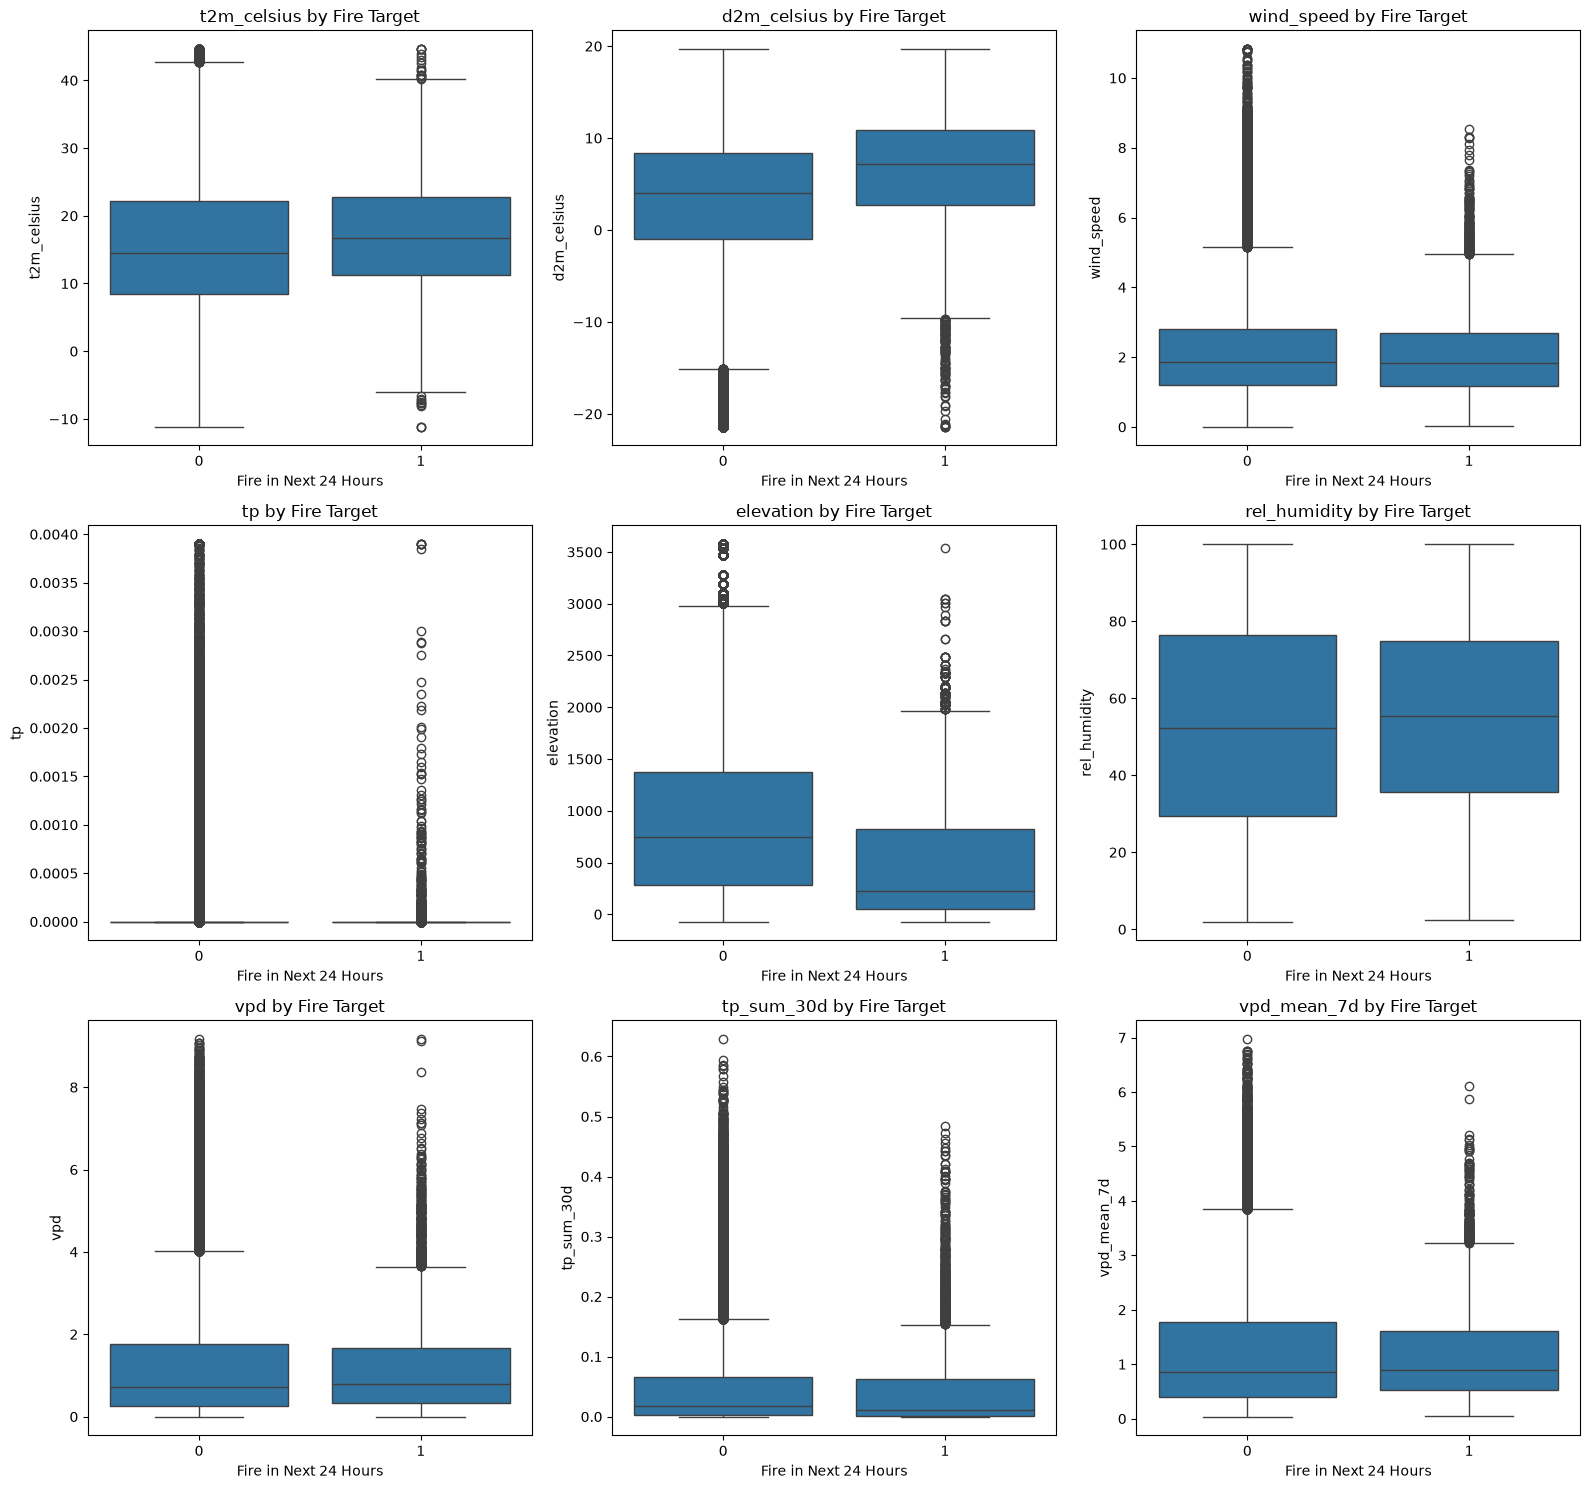

In [32]:
selected_features = ["t2m_celsius", "d2m_celsius", "wind_speed", "tp", "elevation", "rel_humidity", "vpd"]
selected_features += [f for f in ("tp_sum_30d", "vpd_mean_7d") if f in plot_sample.columns]

n_cols = 3
n_rows = int(np.ceil(len(selected_features) / n_cols))
plt.figure(figsize=(16, 5 * n_rows))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=plot_sample, x=target, y=feature)
    plt.title(f"{feature} by Fire Target")
    plt.xlabel("Fire in Next 24 Hours")
plt.tight_layout()
plt.show()

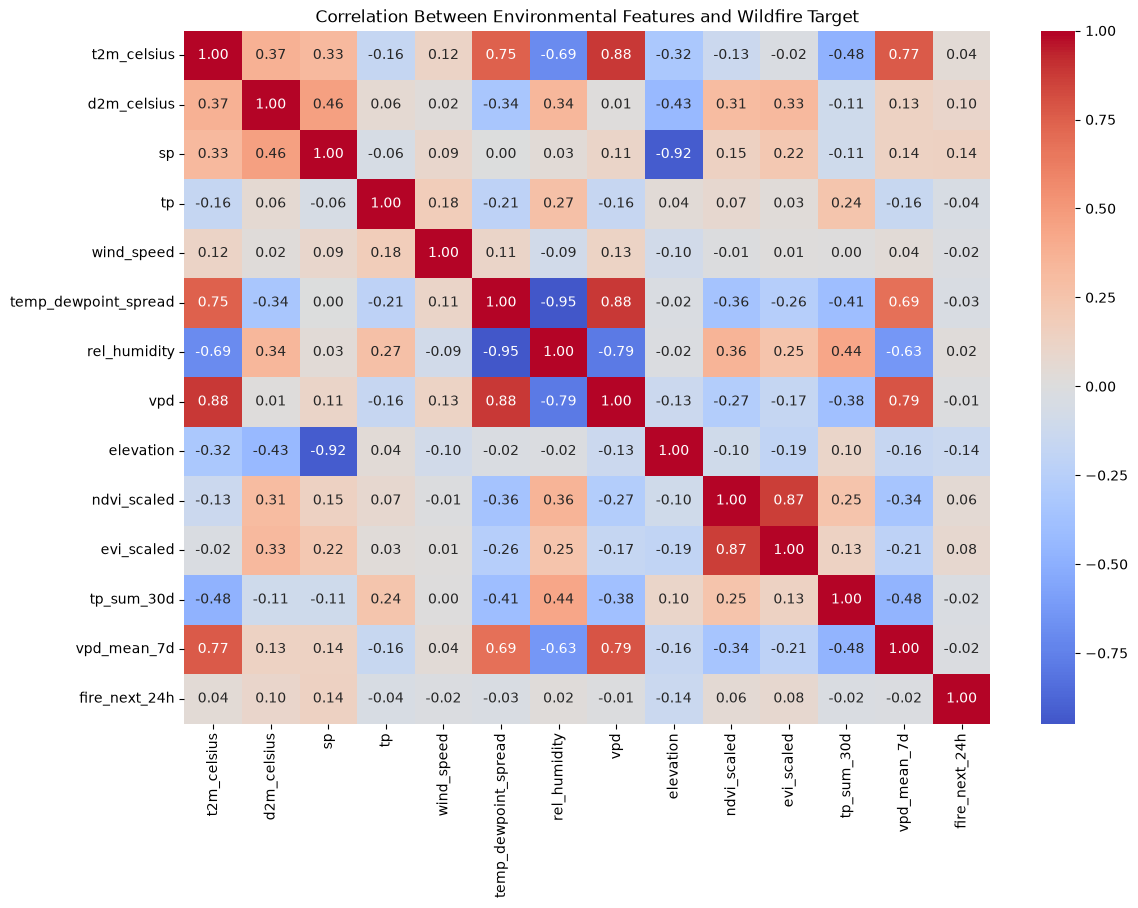

In [33]:
correlation_features = [
    "t2m_celsius", "d2m_celsius", "sp", "tp", "wind_speed",
    "temp_dewpoint_spread", "rel_humidity", "vpd",
    "elevation", "ndvi_scaled", "evi_scaled",
]
correlation_features += [f for f in ("tp_sum_30d", "vpd_mean_7d") if f in plot_sample.columns]
correlation_features += [target]

plt.figure(figsize=(13, 9))
correlation_matrix = plot_sample[correlation_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Environmental Features and Wildfire Target")
plt.show()

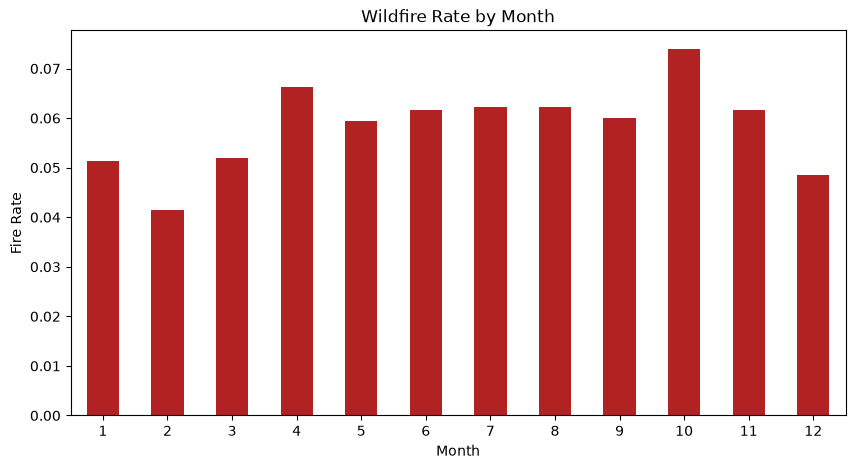

In [34]:
df_clean["month"] = df_clean["valid_time"].dt.month
monthly_fire_rate = df_clean.groupby("month")[target].mean()

plt.figure(figsize=(10, 5))
monthly_fire_rate.plot(kind="bar", color="firebrick")
plt.title("Wildfire Rate by Month")
plt.xlabel("Month")
plt.ylabel("Fire Rate")
plt.xticks(rotation=0)
plt.show()


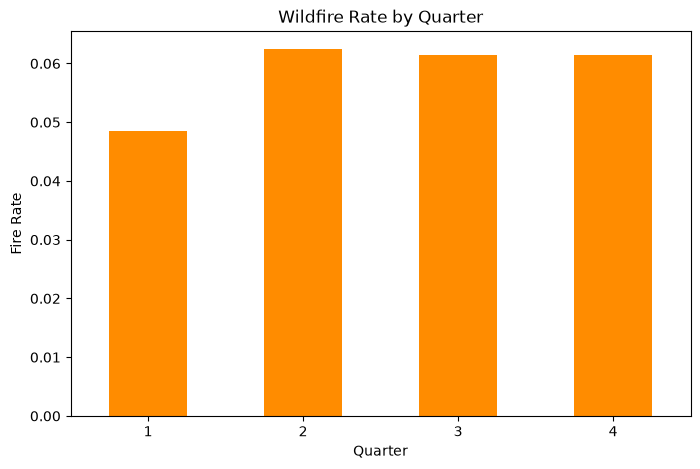

In [35]:
df_clean["quarter"] = df_clean["valid_time"].dt.quarter
quarter_fire_rate = df_clean.groupby("quarter")[target].mean()

plt.figure(figsize=(8, 5))
quarter_fire_rate.plot(kind="bar", color="darkorange")
plt.title("Wildfire Rate by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Fire Rate")
plt.xticks(rotation=0)
plt.show()


### EDA Findings

The distributions of environmental features differ between fire and
non-fire observations. Wind speed, temperature, atmospheric dryness
(temperature-dew point spread, relative humidity, vapour-pressure deficit),
vegetation indices, and precipitation (including the recent rain history)
may contribute to wildfire occurrence.

Monthly and quarterly wildfire rates are analyzed instead of restricting the
data to a single season — all seasons are retained so we don't discard
potentially important environmental conditions.

These observations guide feature engineering and modeling, but correlation
alone is not interpreted as causation.

## 7. Time-Based Feature Engineering

In [36]:
# Extract remaining time-based features
# (month and quarter were already created above for the EDA plots)
df_clean["hour"] = df_clean["valid_time"].dt.hour
df_clean["day_of_year"] = df_clean["valid_time"].dt.dayofyear
df_clean["year"] = df_clean["valid_time"].dt.year


In [37]:
# Encode cyclical time patterns, so e.g. December/January and 23:00/00:00
# are "close" to the model instead of maximally far apart.
# (hour is in UTC, which is consistent across California's single time zone band.)
df_clean["month_sin"] = np.sin(2 * np.pi * df_clean["month"] / 12).astype("float32")
df_clean["month_cos"] = np.cos(2 * np.pi * df_clean["month"] / 12).astype("float32")
df_clean["hour_sin"] = np.sin(2 * np.pi * df_clean["hour"] / 24).astype("float32")
df_clean["hour_cos"] = np.cos(2 * np.pi * df_clean["hour"] / 24).astype("float32")

# Day-of-year gives a smoother seasonal signal than the month (fire season starts and ends gradually)
df_clean["doy_sin"] = np.sin(2 * np.pi * df_clean["day_of_year"] / 365.25).astype("float32")
df_clean["doy_cos"] = np.cos(2 * np.pi * df_clean["day_of_year"] / 365.25).astype("float32")

# Wind direction (meteorological convention: the direction the wind comes FROM).
# Offshore north-easterly winds (Santa Ana type) are a classic California fire driver.
wind_dir_rad = np.arctan2(-df_clean["u10"], -df_clean["v10"])
df_clean["wind_dir_sin"] = np.sin(wind_dir_rad).astype("float32")
df_clean["wind_dir_cos"] = np.cos(wind_dir_rad).astype("float32")
del wind_dir_rad

### Feature groups

Features are organised in groups so that their usefulness can be **measured on
the validation set** (Section 10.3) instead of assumed:

| Group | Features | Available at prediction time from |
|---|---|---|
| base | raw ERA5 / MODIS / SRTM variables, wind speed, temperature-dew point spread, cyclical month and hour | the current observation |
| derived weather / season | relative humidity, VPD, day-of-year, wind direction | the current observation |
| antecedent history | rain over 24 h / 7 d / 30 d, mean VPD, temperature and wind over the recent past | the recent weather history of the cell |
| location | latitude, longitude | the grid-cell coordinates |

An optional feature, `fire_prev_24h` ("was a fire detected in this cell during
the previous 24 hours?"), is available behind `USE_RECENT_FIRE_FEATURE`. It is
**off by default**: fires persist for days, so this feature makes the task
"is the fire that is burning right now going to be detected again?" instead of
"will an ignition-prone environment produce a fire?". It usually inflates the
scores considerably and would change the problem definition given in the
Introduction, so it should only be enabled deliberately (and reported as such).

In [38]:
BASE_FEATURES = [
    "u10", "v10", "t2m_celsius", "d2m_celsius", "sp", "tp",
    "land_cover", "elevation", "ndvi_scaled", "evi_scaled",
    "pixel_reliability", "vi_quality", "wind_speed", "temp_dewpoint_spread",
    "month_sin", "month_cos", "hour_sin", "hour_cos",
]
DERIVED_FEATURES = ["rel_humidity", "vpd", "doy_sin", "doy_cos", "wind_dir_sin", "wind_dir_cos"]
LOCATION_FEATURES = ["latitude", "longitude"]

# Cumulative candidate feature sets (each set contains the previous one)
feature_sets = {}
current = list(BASE_FEATURES) + list(RECENT_FIRE_FEATURES)
feature_sets["base"] = list(current)

current = current + DERIVED_FEATURES
feature_sets["+ derived weather/season"] = list(current)

if HISTORY_FEATURES:
    current = current + HISTORY_FEATURES
    feature_sets["+ antecedent history"] = list(current)

current = current + LOCATION_FEATURES
feature_sets["+ location"] = list(current)

for name, feats in feature_sets.items():
    print(f"{name:28s}: {len(feats):2d} features")

base                        : 18 features
+ derived weather/season    : 24 features
+ antecedent history        : 31 features
+ location                  : 33 features


In [39]:
# Keep only the columns needed from here on (big memory saving before the split / sampling)
needed_columns = ["valid_time", target] + list(dict.fromkeys(feature_sets[list(feature_sets)[-1]]))
df_clean = df_clean[needed_columns]
gc.collect()

print("df_clean shape:", df_clean.shape)
print(f"df_clean memory: {df_clean.memory_usage(deep=True).sum() / 1024**2:,.0f} MB")

df_clean shape: (11801432, 35)
df_clean memory: 1,643 MB


## 8. Time-Based Train-Validation-Test Split

### Time-Based Data Splitting

Because this project is based on time-series data, a random train-test
split is not appropriate — it could let the model learn from future
observations while predicting earlier ones. The data is therefore split
**chronologically**:

- Training data: January 2024 - October 2024
- Validation data: November 2024 - December 2024
- Testing data: January 2025 onward

Two details protect the evaluation from leakage:

- **24-hour embargo.** The label of a row at time T describes the *next 24
  hours*. A training row from the last day of October would therefore share
  label information with the first validation rows. Rows within 24 hours of a
  split boundary are dropped from the earlier period (`EMBARGO`).
- **Warm-up period.** When antecedent features are used, the first
  `MAX_HISTORY_HOURS` of the record have truncated rolling windows and are not
  used for training.

The validation set is used for feature-group selection, model selection,
hyperparameter tuning and the decision threshold. The test set is not used for
any of these decisions.

Note that the validation period (November-December) is outside the main fire
season, so its fire rate is lower than in training. This is expected for a
forecasting split and is one more reason to rely on rate-independent ranking
metrics (PR-AUC) when comparing models.

In [40]:
# Chronological split expressed as positional masks (no copies of the multi-million-row frame)
vt = df_clean["valid_time"]
train_start = RECORD_START + pd.Timedelta(hours=MAX_HISTORY_HOURS) if HISTORY_FEATURES else RECORD_START
train_end = VAL_START - EMBARGO
val_end = TEST_START - EMBARGO

split_masks = {
    "train": ((vt >= train_start) & (vt < train_end)).to_numpy(),
    "validation": ((vt >= VAL_START) & (vt < val_end)).to_numpy(),
    "test": (vt >= TEST_START).to_numpy(),
}
y_all = df_clean[target].to_numpy()

class_idx = {}          # split -> (positions of fire rows, positions of no-fire rows)
summary_rows = []
vt_values = vt.to_numpy()
for name, mask in split_masks.items():
    assert mask.any(), f"The {name} split is empty - check VAL_START / TEST_START and the data period."
    pos = np.flatnonzero(mask & (y_all == 1))
    neg = np.flatnonzero(mask & (y_all == 0))
    class_idx[name] = (pos, neg)
    summary_rows.append({
        "split": name,
        "from": pd.Timestamp(vt_values[mask].min()),
        "to": pd.Timestamp(vt_values[mask].max()),
        "rows": len(pos) + len(neg),
        "fire rows": len(pos),
        "fire rate %": round(100 * len(pos) / (len(pos) + len(neg)), 3),
    })

split_summary = pd.DataFrame(summary_rows).set_index("split")
n_dropped = len(df_clean) - int(split_summary["rows"].sum())
print(f"Rows removed by the embargo / warm-up period: {n_dropped:,}")
split_summary

Rows removed by the embargo / warm-up period: 516,792


,from,to,rows,fire rows,fire rate %
split,,,,,
train,2024-01-31,2024-10-30 23:00:00,4423152,270967,6.126
validation,2024-11-01,2024-12-30 23:00:00,968392,54908,5.670
test,2025-01-01,2025-12-31 23:00:00,5893096,344547,5.847


## 9. Handling Class Imbalance and Dataset Size

Fire observations are rare, so a model trained on the raw distribution can reach
~97% accuracy by never predicting fire, and most learners will do exactly that.
The imbalance is therefore attacked with several complementary levers. All of
them act **only on the training data or on the decision rule**; the validation
and test sets keep the real class ratio, so the reported metrics reflect how the
model would behave in production.

1. **Keep every fire row.** Random undersampling is applied to the *no-fire*
   class only. The training sample contains all fire observations and at most
   `NEG_TO_POS_RATIO` no-fire rows per fire row. Fire rows are the scarce
   resource of this problem and are never discarded (unless they alone would
   fill more than half of `MAX_TRAIN_ROWS`); the size cap shrinks the no-fire
   class only. A moderate ratio (instead of a hard 1:1) keeps more of the
   variety of no-fire conditions, which is what teaches the model to separate
   fire weather from ordinary weather.
2. **Class weights.** Every model is trained with `class_weight`, so a missed
   fire costs more than a false alarm during training. The tuning search
   compares weighted and unweighted variants on the validation set.
3. **Imbalance-aware metrics.** Models are ranked by **PR-AUC** (average
   precision), which — unlike ROC-AUC and Accuracy — is sensitive to how well
   the rare class is ranked. The no-skill PR-AUC equals the fire rate.
4. **Decision-threshold tuning.** The default 0.5 cut-off is arbitrary for a
   rare event. The threshold is chosen on the validation set by maximising
   **F-beta with beta = 2** (Recall counts more than Precision, because a missed
   fire is costlier than a false alarm), or alternatively by targeting a given
   Recall (`THRESHOLD_STRATEGY`).
5. **Probability correction.** Undersampling and class weights inflate the
   predicted probabilities. Because the objective of the project is to
   *estimate the probability of a wildfire*, the scores are mapped back to the
   real-world base rate with the standard prior-shift correction
   (Section 13). The decision threshold is applied to the raw score.

Synthetic oversampling (SMOTE) is deliberately **not** used: consecutive hourly
rows of the same fire are already near-duplicates, the feature space mixes
continuous and categorical variables, and the fire class already contains a
large number of real observations, so interpolated points would add little
information while making the training set much larger.

Two size-only steps keep the pipeline fast: the training sample is capped at
`MAX_TRAIN_ROWS`, and the validation and test sets are reduced to stratified
random samples of at most `MAX_EVAL_ROWS` rows with the **natural** class ratio
(no balancing).

In [41]:
imbalance_overview = pd.DataFrame({
    split: {
        "fire rows": len(pos),
        "no-fire rows": len(neg),
        "no-fire rows per fire row": round(len(neg) / max(len(pos), 1), 1),
        "fire rate %": round(100 * len(pos) / (len(pos) + len(neg)), 3),
    }
    for split, (pos, neg) in class_idx.items()
}).T
imbalance_overview

,fire rows,no-fire rows,no-fire rows per fire row,fire rate %
train,270967.0,4152185.0,15.3,6.126
validation,54908.0,913484.0,16.6,5.670
test,344547.0,5548549.0,16.1,5.847


In [42]:
rng = np.random.default_rng(RANDOM_STATE)


def build_training_sample(frame, class_idx, splits, ratio, max_rows, rng):
    """Keep EVERY fire row, undersample only the no-fire class.

    `splits` lists the periods that are pooled (["train"] for model selection,
    ["train", "validation"] for the final refit), so exactly the same recipe can
    be re-applied when the model is refit on train + validation.
    """
    pos_idx = np.concatenate([class_idx[s][0] for s in splits])
    neg_idx = np.concatenate([class_idx[s][1] for s in splits])
    n_pos_available, n_neg_available = len(pos_idx), len(neg_idx)

    # Fire rows are only thinned in the extreme case where they alone would fill half of the cap
    if n_pos_available > max_rows // 2:
        pos_idx = rng.choice(pos_idx, size=max_rows // 2, replace=False)
    n_pos = len(pos_idx)

    # Only the no-fire class is undersampled; the size cap also shrinks the no-fire class only
    n_neg = int(min(n_neg_available, ratio * n_pos, max_rows - n_pos))
    neg_idx = rng.choice(neg_idx, size=n_neg, replace=False)

    rows = np.sort(np.concatenate([pos_idx, neg_idx]))
    sample = frame.iloc[rows].sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    recipe = {
        "fire_rows_kept": n_pos,
        "fire_rows_available": n_pos_available,
        "nofire_rows_kept": n_neg,
        "nofire_rows_available": n_neg_available,
        "natural_fire_rate": n_pos_available / (n_pos_available + n_neg_available),
        "sample_fire_rate": n_pos / (n_pos + n_neg),
    }
    return sample, recipe


def stratified_eval_sample(frame, class_idx, split, max_rows, rng):
    """Random sample of at most `max_rows` rows that keeps the NATURAL fire / no-fire ratio."""
    pos_idx, neg_idx = class_idx[split]
    frac = min(1.0, max_rows / (len(pos_idx) + len(neg_idx)))
    pos = rng.choice(pos_idx, size=int(round(len(pos_idx) * frac)), replace=False)
    neg = rng.choice(neg_idx, size=int(round(len(neg_idx) * frac)), replace=False)
    rows = np.sort(np.concatenate([pos, neg]))
    return frame.iloc[rows].sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


# (a) training sample used for feature selection, model selection and tuning
train_balanced, train_recipe = build_training_sample(
    df_clean, class_idx, ["train"], NEG_TO_POS_RATIO, MAX_TRAIN_ROWS, rng
)
# (b) identical recipe on train + validation, used for the final refit
trainval_balanced, trainval_recipe = build_training_sample(
    df_clean, class_idx, ["train", "validation"], NEG_TO_POS_RATIO, MAX_TRAIN_ROWS, rng
)
# (c) validation / test samples keep the natural class ratio
validation_df = stratified_eval_sample(df_clean, class_idx, "validation", MAX_EVAL_ROWS, rng)
test_df = stratified_eval_sample(df_clean, class_idx, "test", MAX_EVAL_ROWS, rng)

print("Training sample (train period)")
print(f"  fire rows kept: {train_recipe['fire_rows_kept']:,} of {train_recipe['fire_rows_available']:,}"
      f" | no-fire rows kept: {train_recipe['nofire_rows_kept']:,} of {train_recipe['nofire_rows_available']:,}")
print(f"  fire share of the sample: {train_recipe['sample_fire_rate']:.1%}"
      f" (natural fire rate of the period: {train_recipe['natural_fire_rate']:.2%})")
print("Training sample (train + validation, for the final refit)")
print(f"  fire rows kept: {trainval_recipe['fire_rows_kept']:,} of {trainval_recipe['fire_rows_available']:,}"
      f" | no-fire rows kept: {trainval_recipe['nofire_rows_kept']:,}")
print("\nValidation sample:", validation_df.shape, f"| fire rate {validation_df[target].mean():.3%}")
print("Test sample:      ", test_df.shape, f"| fire rate {test_df[target].mean():.3%}")

Training sample (train period)
  fire rows kept: 270,967 of 270,967 | no-fire rows kept: 929,033 of 4,152,185
  fire share of the sample: 22.6% (natural fire rate of the period: 6.13%)
Training sample (train + validation, for the final refit)
  fire rows kept: 325,875 of 325,875 | no-fire rows kept: 874,125

Validation sample: (400000, 35) | fire rate 5.670%
Test sample:       (400000, 35) | fire rate 5.847%


In [43]:
# Free the big objects that are no longer needed.
# (Run this cell only after you are happy with the sampling settings above: to change
# NEG_TO_POS_RATIO afterwards, re-run the notebook from Section 3.)
del df_clean, data, target_values, y_all, vt, vt_values, split_masks
gc.collect()

54804

## 10. Data Preprocessing and Feature-Set Selection

### 10.1 Preprocessing pipeline

Numeric features are standardised and `land_cover` is one-hot encoded. The
transformer is always fit on the training sample only. `sparse_threshold=0`
forces a dense output, which `HistGradientBoostingClassifier` requires.

In [44]:
import sklearn
from packaging.version import Version
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

assert Version(sklearn.__version__) >= Version("1.2"), (
    "scikit-learn >= 1.2 is required (class_weight support in HistGradientBoostingClassifier)"
)

categorical_features = ["land_cover"]


def make_preprocessor(feature_list):
    numeric = [f for f in feature_list if f not in categorical_features]
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric),
            ("categorical", OneHotEncoder(handle_unknown="ignore", dtype=np.float32), categorical_features),
        ],
        sparse_threshold=0.0,
    )

### 10.2 Evaluation helpers

Helpers shared by feature selection, model selection, tuning and the final
evaluation. Thresholds are read from the full precision-recall curve (every
distinct score is a candidate), not from a coarse grid: for a rare event the
best cut-off is often far below 0.5 and a 0.05-step grid can miss it entirely.

In [45]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    classification_report, confusion_matrix, brier_score_loss,
)


def get_scores(model, X):
    """Continuous fire score (probability-like) for the positive class."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def fbeta_from_pr(precision, recall, beta):
    b2 = beta ** 2
    denom = b2 * precision + recall
    return np.divide((1 + b2) * precision * recall, denom, out=np.zeros_like(denom), where=denom > 0)


def threshold_curve(y_true, y_score, beta=BETA):
    """Precision / Recall / F1 / F-beta at every distinct score threshold."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    precision, recall = precision[:-1], recall[:-1]          # align with `thresholds`
    return pd.DataFrame({
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": fbeta_from_pr(precision, recall, 1.0),
        "fbeta": fbeta_from_pr(precision, recall, beta),
    })


def best_threshold_for(y_true, y_score, strategy=THRESHOLD_STRATEGY, beta=BETA, target_recall=TARGET_RECALL):
    """Pick the decision threshold according to the configured strategy."""
    curve = threshold_curve(y_true, y_score, beta)
    if strategy == "fbeta":
        row = curve.loc[curve["fbeta"].idxmax()]
    elif strategy == "target_recall":
        ok = curve[curve["recall"] >= target_recall]
        row = ok.loc[ok["precision"].idxmax()] if len(ok) else curve.loc[curve["recall"].idxmax()]
    else:
        raise ValueError(f"Unknown THRESHOLD_STRATEGY: {strategy}")
    return {k: float(row[k]) for k in ("threshold", "precision", "recall", "f1", "fbeta")}


def evaluate_scores(y_true, y_score, threshold):
    """All metrics at a given decision threshold (PR-AUC / ROC-AUC do not depend on it)."""
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "fbeta": fbeta_score(y_true, y_pred, beta=BETA, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "alert_rate": float(y_pred.mean()),      # share of all cell-hours flagged as "fire"
    }


def evaluate_model(model, X, y, threshold=0.5):
    return evaluate_scores(y, get_scores(model, X), threshold)


def operating_points(y_true, y_score, recall_targets=(0.6, 0.7, 0.8, 0.9)):
    """Thresholds (and the precision they cost) for several Recall targets."""
    rows = []
    for r in recall_targets:
        b = best_threshold_for(y_true, y_score, strategy="target_recall", target_recall=r)
        rows.append({"target_recall": r, "threshold": b["threshold"],
                     "precision": b["precision"], "recall": b["recall"]})
    return pd.DataFrame(rows)


# ---- probability correction (undersampling / class weights inflate raw probabilities) ----
def effective_training_prior(class_weight, n_fire, n_nofire):
    """Fire share the model effectively 'sees' during training, after resampling AND class weights."""
    if class_weight in ("balanced", "balanced_subsample"):
        return 0.5
    if class_weight is None:
        w1, w0 = 1.0, 1.0
    else:
        w1, w0 = float(class_weight[1]), float(class_weight[0])
    return (w1 * n_fire) / (w1 * n_fire + w0 * n_nofire)


def to_real_world_probability(p, train_prior, true_prior):
    """Prior-shift (odds) correction from the training prior to the real-world fire rate."""
    p = np.clip(np.asarray(p, dtype="float64"), 1e-9, 1 - 1e-9)
    odds = p / (1 - p) * (true_prior / (1 - true_prior)) / (train_prior / (1 - train_prior))
    return odds / (1 + odds)

### 10.3 Feature-group ablation

The added feature groups (Section 7) are only useful if they help on data the
model has not seen. A quick, identically configured gradient-boosting model is
trained on each cumulative feature set and scored on the validation set. A
larger set is adopted only if it improves validation **PR-AUC** by at least
`MIN_RELATIVE_GAIN` (1% by default) over the best smaller set — a small,
noise-level gain does not justify extra inputs (which also have to be supplied
at prediction time).

In [46]:
from sklearn.ensemble import HistGradientBoostingClassifier


def quick_validate(feature_list):
    pre = make_preprocessor(feature_list)
    X_tr = pre.fit_transform(train_balanced[feature_list])
    X_va = pre.transform(validation_df[feature_list])
    clf = HistGradientBoostingClassifier(
        class_weight="balanced", learning_rate=0.1, max_iter=300,
        early_stopping=True, n_iter_no_change=15, random_state=RANDOM_STATE,
    )
    clf.fit(X_tr, train_balanced[target])
    s = clf.predict_proba(X_va)[:, 1]
    best = best_threshold_for(validation_df[target], s)
    return {
        "n_features": len(feature_list),
        "val_pr_auc": average_precision_score(validation_df[target], s),
        "val_roc_auc": roc_auc_score(validation_df[target], s),
        "recall_at_best": best["recall"],
        "precision_at_best": best["precision"],
        "fbeta_at_best": best["fbeta"],
        "trees": clf.n_iter_,
    }


ablation_rows = {}
for name, feats in feature_sets.items():
    t0 = time.time()
    ablation_rows[name] = quick_validate(feats)
    print(f"{name:28s} done in {time.time() - t0:5.1f}s | val PR-AUC = {ablation_rows[name]['val_pr_auc']:.4f}")

ablation_df = pd.DataFrame(ablation_rows).T
print(f"\nNo-skill PR-AUC on validation (= fire rate): {validation_df[target].mean():.4f}")
ablation_df

base                         done in  49.7s | val PR-AUC = 0.3905
+ derived weather/season     done in  43.9s | val PR-AUC = 0.3572
+ antecedent history         done in  48.8s | val PR-AUC = 0.3583
+ location                   done in  52.6s | val PR-AUC = 0.4164

No-skill PR-AUC on validation (= fire rate): 0.0567


,n_features,val_pr_auc,val_roc_auc,recall_at_best,precision_at_best,fbeta_at_best,trees
base,18.0,0.390531,0.825075,0.580203,0.254649,0.462060,300.0
+ derived weather/season,24.0,0.357225,0.819066,0.542460,0.275815,0.454569,300.0
+ antecedent history,31.0,0.358345,0.812641,0.561905,0.265191,0.459157,300.0
+ location,33.0,0.416354,0.839178,0.566402,0.300330,0.481149,300.0


In [47]:
# Greedy, parsimonious choice: adopt a larger set only if PR-AUC improves by >= MIN_RELATIVE_GAIN
selected_set_name = list(feature_sets)[0]
best_pr_auc = ablation_df.loc[selected_set_name, "val_pr_auc"]
for name in list(feature_sets)[1:]:
    candidate_pr_auc = ablation_df.loc[name, "val_pr_auc"]
    if candidate_pr_auc >= best_pr_auc * (1 + MIN_RELATIVE_GAIN):
        selected_set_name, best_pr_auc = name, candidate_pr_auc

features_engineered = feature_sets[selected_set_name]
numeric_features = [f for f in features_engineered if f not in categorical_features]

print("Selected feature set:", selected_set_name, f"(validation PR-AUC = {best_pr_auc:.4f})")
print("Number of model features:", len(features_engineered))
print(features_engineered)

Selected feature set: + location (validation PR-AUC = 0.4164)
Number of model features: 33
['u10', 'v10', 't2m_celsius', 'd2m_celsius', 'sp', 'tp', 'land_cover', 'elevation', 'ndvi_scaled', 'evi_scaled', 'pixel_reliability', 'vi_quality', 'wind_speed', 'temp_dewpoint_spread', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'rel_humidity', 'vpd', 'doy_sin', 'doy_cos', 'wind_dir_sin', 'wind_dir_cos', 'tp_sum_24h', 'tp_sum_7d', 'tp_sum_30d', 'vpd_mean_24h', 'vpd_mean_7d', 't2m_mean_7d', 'wind_mean_24h', 'latitude', 'longitude']


### 10.4 Fit the preprocessor on the selected features

The preprocessor is fit on the training sample only and then applied to the
validation set. The test set is transformed only inside the final pipeline
(Section 13).

In [48]:
X_train = train_balanced[features_engineered]
y_train = train_balanced[target]
X_validation = validation_df[features_engineered]
y_validation = validation_df[target]
X_test = test_df[features_engineered]
y_test = test_df[target]

preprocessor = make_preprocessor(features_engineered)
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)

processed_feature_names = preprocessor.get_feature_names_out()

print("Processed X_train shape:     ", X_train_processed.shape)
print("Processed X_validation shape:", X_validation_processed.shape)
print("Number of output features after preprocessing:", len(processed_feature_names))

Processed X_train shape:      (1200000, 45)
Processed X_validation shape: (400000, 45)
Number of output features after preprocessing: 45


## 11. Model Building

At least three classification algorithms are trained on the preprocessed
training sample, chosen to cover different modeling families. Every model uses
`class_weight`, so that missing a fire is penalised more than a false alarm:

- **Logistic Regression** — a fast, interpretable linear baseline.
- **Random Forest** — a bagging ensemble that captures non-linear feature
  interactions (`balanced_subsample` weights, bounded tree size).
- **HistGradientBoostingClassifier** — scikit-learn's histogram-based
  gradient boosting, which scales well to large tabular datasets (similar
  idea to LightGBM/XGBoost) without needing an extra dependency. It uses
  early stopping to choose the number of trees.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, max_samples=0.3,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, random_state=RANDOM_STATE,
    ),
}

fitted_models = {}
training_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_processed, y_train)
    training_times[name] = time.time() - start
    fitted_models[name] = model
    print(f"Trained {name:22s} in {training_times[name]:6.1f}s")

Trained Logistic Regression    in   10.1s
Trained Random Forest          in  122.6s
Trained HistGradientBoosting   in   80.9s


## 12. Model Evaluation

Because the target is naturally imbalanced, **Accuracy alone is misleading** —
a model that always predicts "no fire" on the real-world validation/test
distribution would still score ~97-98% accuracy while being useless. The
evaluation therefore emphasises:

- **PR-AUC (average precision)** — threshold-free and sensitive to the rare
  class; the no-skill baseline equals the fire rate. Used to rank models.
- **Recall and Precision on the fire class**, and **F2** (Recall weighted more
  than Precision), at the decision threshold chosen on the validation set:
  missing an actual wildfire (a false negative) is far more costly than a false
  alarm.
- ROC-AUC and Accuracy are reported for completeness. ROC-AUC looks optimistic
  under heavy imbalance because the huge no-fire class keeps the false-positive
  rate small.

Each model is evaluated at **its own best validation threshold**, so the models
are compared at their respective best operating points and not at an arbitrary
0.5 cut-off.

In [50]:
validation_scores = {
    name: get_scores(model, X_validation_processed) for name, model in fitted_models.items()
}

validation_results = {}
for name, scores in validation_scores.items():
    thr = best_threshold_for(y_validation, scores)["threshold"]
    validation_results[name] = evaluate_scores(y_validation, scores, thr)

results_df = pd.DataFrame(validation_results).T.sort_values("pr_auc", ascending=False)
print(f"No-skill PR-AUC on validation (= fire rate): {y_validation.mean():.4f}")
results_df

No-skill PR-AUC on validation (= fire rate): 0.0567


,threshold,pr_auc,roc_auc,precision,recall,f1,fbeta,accuracy,alert_rate
Random Forest,0.241708,0.425943,0.840421,0.317258,0.568519,0.407252,0.490781,0.906165,0.101605
HistGradientBoosting,0.256979,0.404202,0.829617,0.294761,0.554718,0.384964,0.471545,0.899500,0.106705
Logistic Regression,0.485720,0.142661,0.728908,0.132044,0.574295,0.214720,0.343920,0.761822,0.246603


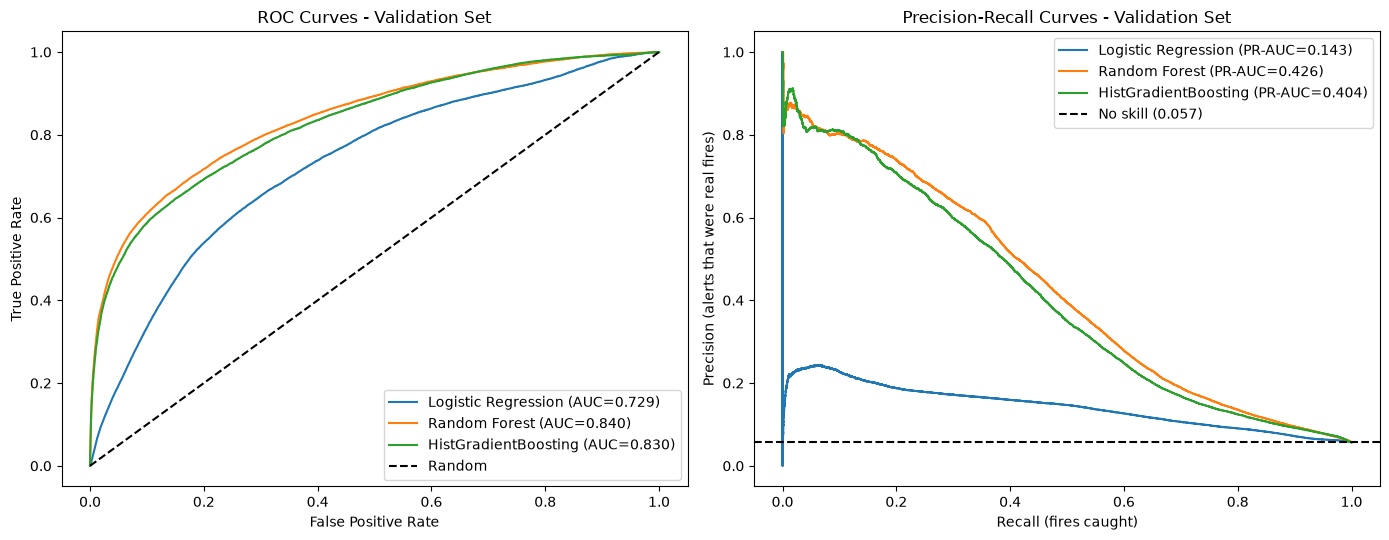

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, scores in validation_scores.items():
    fpr, tpr, _ = roc_curve(y_validation, scores)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_validation, scores):.3f})")
    prec, rec, _ = precision_recall_curve(y_validation, scores)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_validation, scores):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - Validation Set")
axes[0].legend()

axes[1].axhline(y_validation.mean(), color="k", linestyle="--", label=f"No skill ({y_validation.mean():.3f})")
axes[1].set_xlabel("Recall (fires caught)")
axes[1].set_ylabel("Precision (alerts that were real fires)")
axes[1].set_title("Precision-Recall Curves - Validation Set")
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
# Select the best model based on validation PR-AUC (the metric that reflects the rare fire class)
best_model_name = results_df["pr_auc"].idxmax()
best_model = fitted_models[best_model_name]

print("Best model on validation PR-AUC:", best_model_name)
results_df

Best model on validation PR-AUC: Random Forest


,threshold,pr_auc,roc_auc,precision,recall,f1,fbeta,accuracy,alert_rate
Random Forest,0.241708,0.425943,0.840421,0.317258,0.568519,0.407252,0.490781,0.906165,0.101605
HistGradientBoosting,0.256979,0.404202,0.829617,0.294761,0.554718,0.384964,0.471545,0.899500,0.106705
Logistic Regression,0.485720,0.142661,0.728908,0.132044,0.574295,0.214720,0.343920,0.761822,0.246603


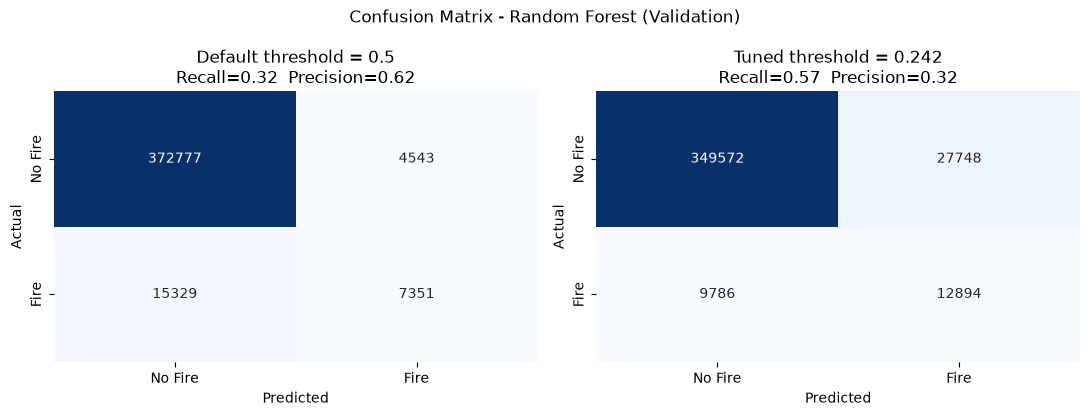

Classification report for Random Forest at the tuned threshold (0.242), validation set:

              precision    recall  f1-score   support

           0      0.973     0.926     0.949    377320
           1      0.317     0.569     0.407     22680

    accuracy                          0.906    400000
   macro avg      0.645     0.747     0.678    400000
weighted avg      0.936     0.906     0.918    400000



In [53]:
best_scores = validation_scores[best_model_name]
best_thr = best_threshold_for(y_validation, best_scores)["threshold"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, thr, title in zip(axes, (0.5, best_thr), ("Default threshold = 0.5", f"Tuned threshold = {best_thr:.3f}")):
    y_pred = (best_scores >= thr).astype(int)
    cm = confusion_matrix(y_validation, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
    rec = recall_score(y_validation, y_pred, zero_division=0)
    prec = precision_score(y_validation, y_pred, zero_division=0)
    ax.set_title(f"{title}\nRecall={rec:.2f}  Precision={prec:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle(f"Confusion Matrix - {best_model_name} (Validation)")
plt.tight_layout()
plt.show()

print(f"Classification report for {best_model_name} at the tuned threshold ({best_thr:.3f}), validation set:\n")
print(classification_report(y_validation, (best_scores >= best_thr).astype(int), digits=3, zero_division=0))

**Model comparison and justification:** the table and curves above rank the
three models by PR-AUC on the (natural-ratio) validation set. The model
selected as `best_model` is carried forward into hyperparameter tuning in the
next section. If two models are close on PR-AUC, the Recall/Precision trade-off
at their best thresholds (F2 column) is the tie-breaker, since catching real
fires matters more than raw accuracy for this problem.

### Decision Threshold Tuning

A classifier outputs a fire score; the decision threshold decides which scores
raise an alert. The default 0.5 cut-off is arbitrary for a problem where fires
are only ~2-3% of the data, and it is a typical reason why Recall looks weak in
a confusion matrix: many genuinely risky situations get rounded down to "no
fire". Because the model already provides a continuous score, the cut-off can
be moved **without retraining anything**.

The plot below shows how Precision, Recall, F1 and F2 change with the
threshold on the validation set, and the table lists the price (Precision) of
reaching several Recall targets. Lowering the threshold trades Precision for
Recall: more borderline cases are flagged as "fire". The operating point used
by the final model is set by `THRESHOLD_STRATEGY` (F2 by default) and is decided
jointly with the hyperparameters in the next section.

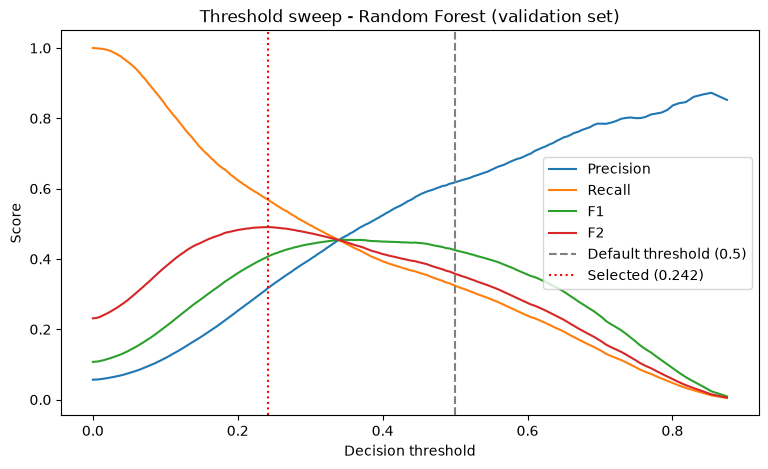

Selected on validation (fbeta): threshold=0.2417 | precision=0.317 | recall=0.569 | F1=0.407 | F2=0.491

Precision you pay for a given Recall target (validation set):


,target_recall,threshold,precision,recall
0,0.6,0.217006,0.278474,0.600044
1,0.7,0.156842,0.188861,0.700000
2,0.8,0.115249,0.135450,0.800000
3,0.9,0.076368,0.094804,0.900000


In [54]:
curve = threshold_curve(y_validation, best_scores)
step = max(1, len(curve) // 2000)
curve_plot = curve.iloc[::step]
sel = best_threshold_for(y_validation, best_scores)

plt.figure(figsize=(9, 5))
plt.plot(curve_plot["threshold"], curve_plot["precision"], label="Precision")
plt.plot(curve_plot["threshold"], curve_plot["recall"], label="Recall")
plt.plot(curve_plot["threshold"], curve_plot["f1"], label="F1")
plt.plot(curve_plot["threshold"], curve_plot["fbeta"], label=f"F{BETA:g}")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.axvline(sel["threshold"], color="red", linestyle=":", label=f"Selected ({sel['threshold']:.3f})")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Threshold sweep - {best_model_name} (validation set)")
plt.legend()
plt.show()

print(f"Selected on validation ({THRESHOLD_STRATEGY}): threshold={sel['threshold']:.4f} | "
      f"precision={sel['precision']:.3f} | recall={sel['recall']:.3f} | F1={sel['f1']:.3f} | F{BETA:g}={sel['fbeta']:.3f}")
print("\nPrecision you pay for a given Recall target (validation set):")
operating_points(y_validation, best_scores)

## 13. Model Optimization

Because this is time-series data, a standard random K-fold cross-validation
(e.g. `GridSearchCV`'s default) would mix future and past rows across folds
and leak information — the same reason a random train/test split was
rejected in section 8.

Instead, hyperparameters for the best model are tuned **against the
already time-based validation set**: each candidate configuration is trained
on the training sample and scored on the validation set (which the model has
never seen), exactly mirroring how the model will be judged in production.

- The search is a **random search** over a grid that also varies
  `class_weight` (how strongly missed fires are penalised) and the model
  capacity / regularisation. The untouched default configuration is always one
  of the candidates, so tuning can never make the result worse than the
  starting point.
- Candidates are **ranked by validation PR-AUC** (threshold-free, focused on the
  fire class). The Recall / Precision / F2 obtained at each candidate's own best
  threshold are logged alongside, and F2 breaks ties. ROC-AUC is deliberately
  not used for ranking: under heavy imbalance it barely reflects the
  Recall/Precision the deployed model would produce.

In [55]:
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, ParameterSampler

param_grids = {
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced", {0: 1, 1: 3}],
    },
    "RandomForestClassifier": {
        "max_depth": [12, 20, None],
        "min_samples_leaf": [2, 5, 20],
        "max_features": ["sqrt", 0.5],
        "class_weight": ["balanced_subsample", "balanced", None],
    },
    "HistGradientBoostingClassifier": {
        "learning_rate": [0.03, 0.05, 0.1],
        "max_iter": [300, 600],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [20, 100, 400],
        "l2_regularization": [0.0, 1.0, 10.0],
        "class_weight": [None, "balanced"],
    },
}

best_model_class = type(best_model).__name__
grid = param_grids.get(best_model_class, {})
n_total = len(ParameterGrid(grid)) if grid else 1
n_candidates = min(N_TUNING_CANDIDATES, n_total)
sampled = list(ParameterSampler(grid, n_iter=n_candidates, random_state=RANDOM_STATE)) if grid else []
candidates = [("default", {})] + [(f"candidate {i}", p) for i, p in enumerate(sampled, 1)]
print(f"Tuning {best_model_class}: {len(candidates)} configurations "
      f"(default + {len(sampled)} sampled from a grid of {n_total})")

tuning_log = []
best_key = (-np.inf, -np.inf)
best_params, best_threshold, best_val_scores = {}, 0.5, None

for label, params in candidates:
    t0 = time.time()
    candidate = clone(best_model).set_params(**params)
    candidate.fit(X_train_processed, y_train)

    y_val_score = get_scores(candidate, X_validation_processed)
    val_pr_auc = average_precision_score(y_validation, y_val_score)
    sel = best_threshold_for(y_validation, y_val_score)

    tuning_log.append({
        "config": label, **params,
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": roc_auc_score(y_validation, y_val_score),
        "val_recall": sel["recall"], "val_precision": sel["precision"],
        "val_fbeta": sel["fbeta"], "threshold": sel["threshold"],
        "seconds": round(time.time() - t0, 1),
    })
    print(f"[{label:12s}] PR-AUC={val_pr_auc:.4f} | F{BETA:g}={sel['fbeta']:.4f} | "
          f"recall={sel['recall']:.3f} | precision={sel['precision']:.3f} | {time.time() - t0:5.1f}s")

    key = (val_pr_auc, sel["fbeta"])
    if key > best_key:
        best_key, best_params, best_threshold, best_val_scores = key, params, sel["threshold"], y_val_score

best_val_pr_auc = best_key[0]
best_val_selection = best_threshold_for(y_validation, best_val_scores)
tuning_log_df = pd.DataFrame(tuning_log).sort_values(["val_pr_auc", "val_fbeta"], ascending=False)

print("\nBest params:", best_params,
      f"| validation PR-AUC: {best_val_pr_auc:.4f}",
      f"| validation F{BETA:g} at tuned threshold: {best_val_selection['fbeta']:.4f}",
      f"| tuned threshold: {best_threshold:.4f}")
tuning_log_df

Tuning RandomForestClassifier: 16 configurations (default + 15 sampled from a grid of 54)
[default     ] PR-AUC=0.4259 | F2=0.4908 | recall=0.569 | precision=0.317 | 128.0s
[candidate 1 ] PR-AUC=0.3726 | F2=0.4599 | recall=0.572 | precision=0.258 |  99.4s
[candidate 2 ] PR-AUC=0.4381 | F2=0.4940 | recall=0.565 | precision=0.329 | 118.9s
[candidate 3 ] PR-AUC=0.4328 | F2=0.4926 | recall=0.560 | precision=0.333 | 120.2s
[candidate 4 ] PR-AUC=0.4254 | F2=0.4853 | recall=0.560 | precision=0.317 | 128.0s
[candidate 5 ] PR-AUC=0.4378 | F2=0.5013 | recall=0.582 | precision=0.322 | 114.8s
[candidate 6 ] PR-AUC=0.4282 | F2=0.4891 | recall=0.618 | precision=0.267 | 297.4s
[candidate 7 ] PR-AUC=0.4386 | F2=0.4950 | recall=0.582 | precision=0.309 | 420.6s
[candidate 8 ] PR-AUC=0.4427 | F2=0.4844 | recall=0.553 | precision=0.324 | 407.2s
[candidate 9 ] PR-AUC=0.4184 | F2=0.4831 | recall=0.597 | precision=0.274 | 264.9s
[candidate 10] PR-AUC=0.4193 | F2=0.4915 | recall=0.571 | precision=0.316 | 110.

,config,val_pr_auc,val_roc_auc,val_recall,val_precision,val_fbeta,threshold,seconds,min_samples_leaf,max_features,max_depth,class_weight
8,candidate 8,0.442713,0.844283,0.552646,0.324161,0.484365,0.250739,407.2,5.0,0.5,NaN,NaN
7,candidate 7,0.438575,0.848361,0.582363,0.309328,0.494982,0.307607,420.6,20.0,0.5,NaN,balanced_subsample
2,candidate 2,0.438135,0.839887,0.564727,0.329035,0.493960,0.241329,118.9,5.0,sqrt,NaN,NaN
5,candidate 5,0.437775,0.840567,0.582099,0.322354,0.501310,0.253739,114.8,20.0,sqrt,20.0,NaN
15,candidate 15,0.432996,0.847403,0.569665,0.316612,0.491154,0.246027,389.7,5.0,0.5,NaN,balanced
3,candidate 3,0.432848,0.837386,0.559877,0.332617,0.492568,0.230833,120.2,2.0,sqrt,NaN,NaN
6,candidate 6,0.428175,0.848923,0.617549,0.266995,0.489111,0.405186,297.4,20.0,0.5,12.0,balanced_subsample
0,default,0.425943,0.840421,0.568519,0.317258,0.490781,0.241708,128.0,NaN,NaN,NaN,NaN
11,candidate 11,0.425943,0.840421,0.568519,0.317258,0.490781,0.241708,151.2,5.0,sqrt,NaN,balanced_subsample
4,candidate 4,0.425374,0.838466,0.559832,0.316665,0.485300,0.180789,128.0,2.0,sqrt,NaN,balanced_subsample


### Final Refit and Held-Out Test Evaluation

The model family (section 12), the feature set (section 10.3), the
hyperparameters and the decision threshold have all been chosen using only the
training and validation periods. The tuned model is now refit on **training +
validation** (standard practice once tuning is finished; November-December add
the late-autumn season the training period lacks) and evaluated on the test
set, which has not been used for any decision.

Two details keep this refit consistent with the tuning stage:

- **The identical sampling recipe is used.** The refit sample is built from the
  training and validation periods with exactly the same rule (all fire rows,
  `NEG_TO_POS_RATIO` no-fire rows per fire row). Adding the validation rows *as
  they are* (natural class ratio) to a rebalanced training sample would change
  the effective fire share the model sees and silently invalidate the threshold
  that was tuned for it.
- **The threshold is applied to the raw model score**, as during tuning. In
  addition, a probability-corrected score (`risk_probability`) is produced
  by mapping the score back to the real-world fire rate; it is what should be
  shown to users as "probability of a fire".

In [56]:
from sklearn.pipeline import Pipeline

final_model = clone(best_model).set_params(**best_params)
final_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(features_engineered)),
    ("model", final_model),
])

fit_frame = trainval_balanced if REFIT_ON_TRAIN_VAL else train_balanced
fit_recipe = trainval_recipe if REFIT_ON_TRAIN_VAL else train_recipe
final_pipeline.fit(fit_frame[features_engineered], fit_frame[target])

# ---- held-out test evaluation (threshold fixed on validation) ----
y_test_score = get_scores(final_pipeline, X_test)
final_test_scores = evaluate_scores(y_test, y_test_score, best_threshold)

print(f"Refit on: {'train + validation' if REFIT_ON_TRAIN_VAL else 'train only'} | "
      f"{len(fit_frame):,} rows | model: {best_model_class} | features: {len(features_engineered)}")
print(f"No-skill PR-AUC on test (= fire rate): {y_test.mean():.4f}")
print(f"\nFinal model on the held-out TEST set (threshold = {best_threshold:.4f}, tuned on validation):")

test_comparison = pd.DataFrame({
    "default threshold (0.5)": evaluate_scores(y_test, y_test_score, 0.5),
    "tuned threshold": final_test_scores,
}).T
test_comparison

Refit on: train + validation | 1,200,000 rows | model: RandomForestClassifier | features: 33
No-skill PR-AUC on test (= fire rate): 0.0585

Final model on the held-out TEST set (threshold = 0.2507, tuned on validation):


,threshold,pr_auc,roc_auc,precision,recall,f1,fbeta,accuracy,alert_rate
default threshold (0.5),0.500000,0.486259,0.88442,0.495629,0.516335,0.505770,0.512056,0.941002,0.060908
tuned threshold,0.250739,0.486259,0.88442,0.290817,0.707817,0.412253,0.550069,0.882003,0.142297


Classification report on the TEST set (threshold = 0.2507):

              precision    recall  f1-score   support

           0      0.980     0.893     0.934    376614
           1      0.291     0.708     0.412     23386

    accuracy                          0.882    400000
   macro avg      0.635     0.800     0.673    400000
weighted avg      0.940     0.882     0.904    400000



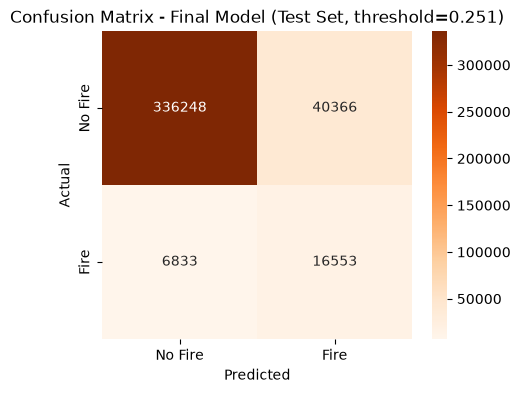

In [57]:
y_test_pred = (y_test_score >= best_threshold).astype(int)

print(f"Classification report on the TEST set (threshold = {best_threshold:.4f}):\n")
print(classification_report(y_test, y_test_pred, digits=3, zero_division=0))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title(f"Confusion Matrix - Final Model (Test Set, threshold={best_threshold:.3f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Choosing a different operating point

The threshold is a business decision as much as a statistical one: a fire
service that can tolerate more false alarms will want higher Recall. The table
shows what each Recall target costs. **Thresholds were obtained on the
validation set** and are only *applied* to the test set here, so the test
numbers remain an honest estimate. To deploy a different operating point, set
`THRESHOLD_STRATEGY = "target_recall"` and `TARGET_RECALL` in the configuration
cell and re-run.

In [58]:
op_val = operating_points(y_validation, best_val_scores)
op_rows = []
for _, row in op_val.iterrows():
    m = evaluate_scores(y_test, y_test_score, row["threshold"])
    m["validation_recall_target"] = row["target_recall"]
    op_rows.append(m)

op_test = pd.DataFrame(op_rows).set_index("validation_recall_target")[
    ["threshold", "recall", "precision", "f1", "fbeta", "alert_rate"]
]
op_test

,threshold,recall,precision,f1,fbeta,alert_rate
validation_recall_target,,,,,,
0.6,0.207378,0.747969,0.253706,0.378894,0.538249,0.172365
0.7,0.141351,0.815659,0.195429,0.315310,0.498954,0.244015
0.8,0.097635,0.866972,0.156631,0.265327,0.454621,0.323610
0.9,0.057817,0.914350,0.120860,0.213500,0.395298,0.442308


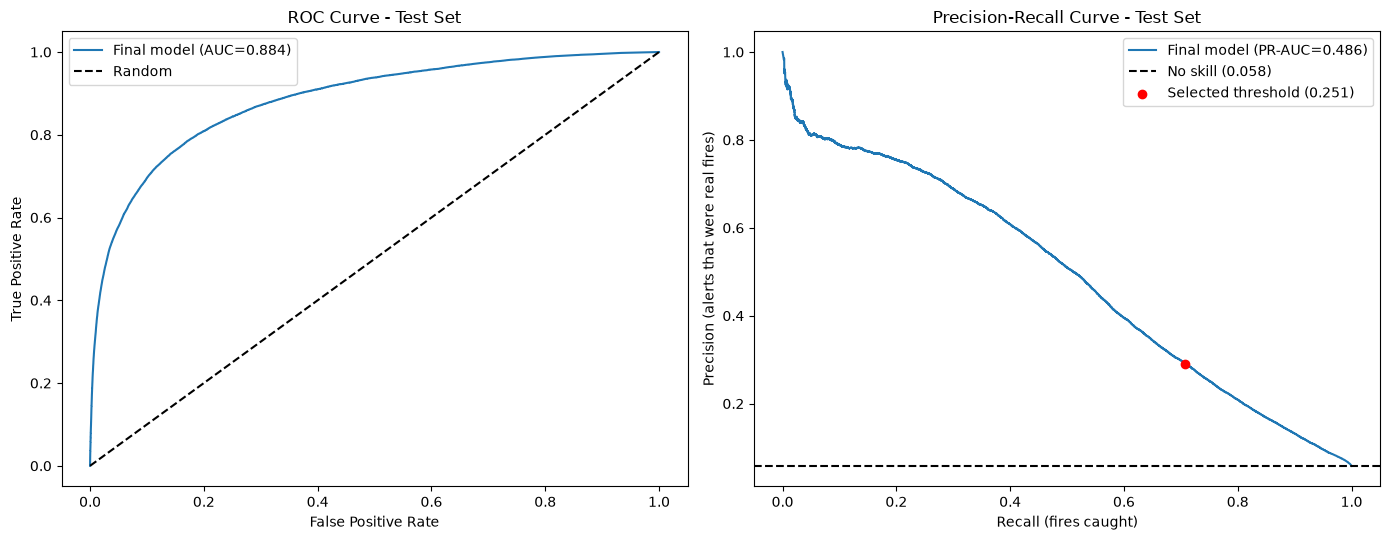

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

fpr, tpr, _ = roc_curve(y_test, y_test_score)
axes[0].plot(fpr, tpr, label=f"Final model (AUC={final_test_scores['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - Test Set")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_test_score)
axes[1].plot(rec, prec, label=f"Final model (PR-AUC={final_test_scores['pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", label=f"No skill ({y_test.mean():.3f})")
axes[1].scatter([final_test_scores["recall"]], [final_test_scores["precision"]], color="red", zorder=5,
                label=f"Selected threshold ({best_threshold:.3f})")
axes[1].set_xlabel("Recall (fires caught)")
axes[1].set_ylabel("Precision (alerts that were real fires)")
axes[1].set_title("Precision-Recall Curve - Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()

### Probability calibration check

Resampling and class weights make the raw scores over-estimate the real fire
probability. The prior-shift correction re-scales the odds from the effective
training fire share back to the real-world fire rate of the training period.
The reliability plot compares the raw and corrected scores with what actually
happened on the test set; the Brier score (lower is better) is compared with
the trivial "always predict the average fire rate" forecast.

The correction is calibrated to the *average* fire rate of the training period,
so it will over-state risk in low-season months and under-state it in the peak
of the fire season; a seasonal recalibration would be the next step for a
production system.

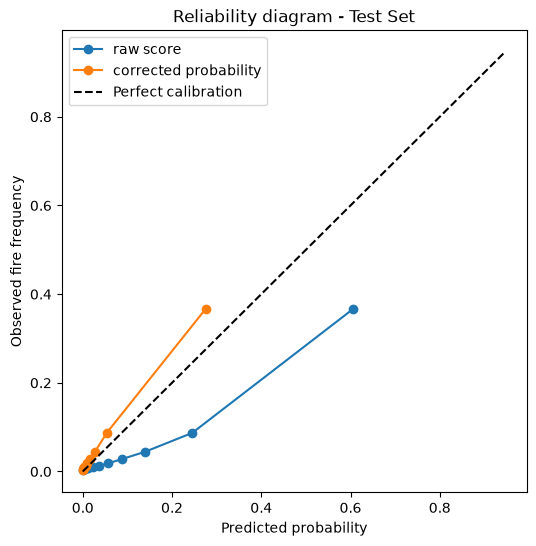

Effective training fire share: 0.272 | real-world fire rate used for the correction: 0.0604


,Brier score
raw score,0.049071
corrected probability,0.040446
constant forecast (test fire rate),0.055047


In [60]:
from sklearn.calibration import calibration_curve

eff_prior = effective_training_prior(
    final_model.get_params().get("class_weight"),
    fit_recipe["fire_rows_kept"], fit_recipe["nofire_rows_kept"],
)
natural_prior = fit_recipe["natural_fire_rate"]

p_raw = np.clip(y_test_score, 0, 1)
p_corrected = to_real_world_probability(y_test_score, eff_prior, natural_prior)

base_rate = float(y_test.mean())
brier_table = pd.Series({
    "raw score": brier_score_loss(y_test, p_raw),
    "corrected probability": brier_score_loss(y_test, p_corrected),
    "constant forecast (test fire rate)": base_rate * (1 - base_rate),
}, name="Brier score")

plt.figure(figsize=(6, 6))
for label, p in (("raw score", p_raw), ("corrected probability", p_corrected)):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
top = max(0.05, float(np.percentile(p_raw, 99.5)))
plt.plot([0, top], [0, top], "k--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed fire frequency")
plt.title("Reliability diagram - Test Set")
plt.legend()
plt.show()

print(f"Effective training fire share: {eff_prior:.3f} | real-world fire rate used for the correction: {natural_prior:.4f}")
brier_table.to_frame()

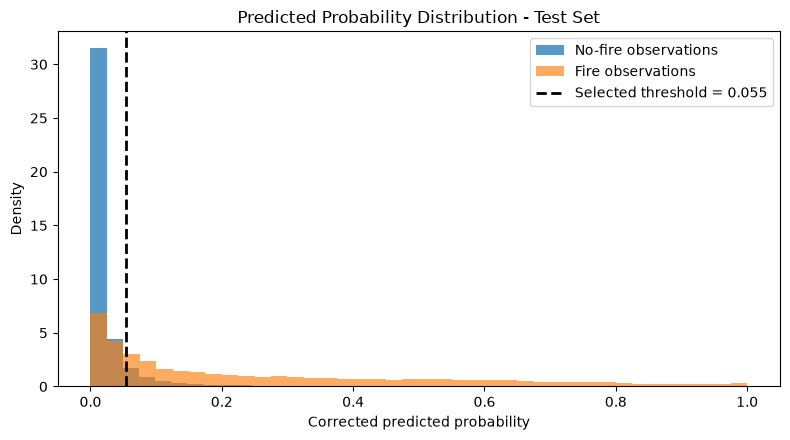

In [64]:
# Predicted probability distribution by actual class (held-out test set)
# Uses corrected probabilities for display, with the threshold translated
# to the same corrected-probability scale.
# Convert the raw-score decision threshold to the corrected-probability scale
threshold_odds = (
    (best_threshold / (1 - best_threshold))
    * (natural_prior / (1 - natural_prior))
    / (eff_prior / (1 - eff_prior))
)
corrected_threshold = threshold_odds / (1 + threshold_odds)

# Build a compact, class-balanced plotting sample so the chart stays readable
plot_df = pd.DataFrame({
    "actual": np.asarray(y_test).astype(int),
    "probability": np.asarray(p_corrected, dtype=float)
})

MAX_PER_CLASS = 50_000
plot_parts = []

for class_value in [0, 1]:
    class_rows = plot_df[plot_df["actual"] == class_value]
    if len(class_rows) > MAX_PER_CLASS:
        class_rows = class_rows.sample(
            n=MAX_PER_CLASS,
            random_state=RANDOM_STATE
        )
    plot_parts.append(class_rows)

probability_plot_df = pd.concat(plot_parts, ignore_index=True)

plt.figure(figsize=(8, 4.5))

plt.hist(
    probability_plot_df.loc[
        probability_plot_df["actual"] == 0, "probability"
    ],
    bins=40,
    density=True,
    alpha=0.75,
    label="No-fire observations"
)

plt.hist(
    probability_plot_df.loc[
        probability_plot_df["actual"] == 1, "probability"
    ],
    bins=40,
    density=True,
    alpha=0.65,
    label="Fire observations"
)

plt.axvline(
    corrected_threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Selected threshold = {corrected_threshold:.3f}"
)

plt.xlabel("Corrected predicted probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution - Test Set")
plt.legend()
plt.tight_layout()
plt.show()

### Which features drive the prediction?

Permutation importance measures how much PR-AUC drops when one feature is
shuffled. It is computed on a random subset of the test sample and is meant for
interpretation only (nothing above was selected with it). Strongly correlated
features (e.g. temperature, VPD and relative humidity) share credit, so the
importance of a single feature should be read as a lower bound.

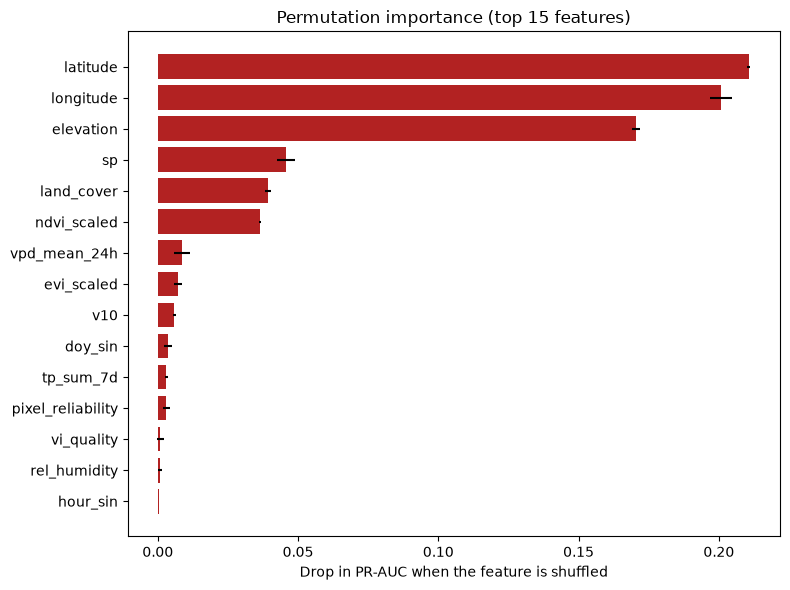

,feature,importance,std
0,latitude,0.210645,0.000588
1,longitude,0.200766,0.003984
2,elevation,0.170377,0.001403
3,sp,0.045743,0.003300
4,land_cover,0.039158,0.001038
5,ndvi_scaled,0.036373,0.000262
6,vpd_mean_24h,0.008609,0.002760
7,evi_scaled,0.007178,0.001291
8,v10,0.005819,0.000563
9,doy_sin,0.003644,0.001294


In [61]:
from sklearn.inspection import permutation_importance

subset = test_df.sample(n=min(50_000, len(test_df)), random_state=RANDOM_STATE)
perm = permutation_importance(
    final_pipeline, subset[features_engineered], subset[target],
    scoring="average_precision", n_repeats=3, random_state=RANDOM_STATE, n_jobs=1,
)
importance_df = (
    pd.DataFrame({"feature": features_engineered,
                  "importance": perm.importances_mean,
                  "std": perm.importances_std})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"], xerr=top["std"], color="firebrick")
plt.xlabel("Drop in PR-AUC when the feature is shuffled")
plt.title("Permutation importance (top 15 features)")
plt.tight_layout()
plt.show()

importance_df.head(15)

PermutationExplainer explainer: 121it [00:23,  4.05it/s]                         
C:\Users\ahmed\AppData\Local\Temp\ipykernel_36524\2976386518.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


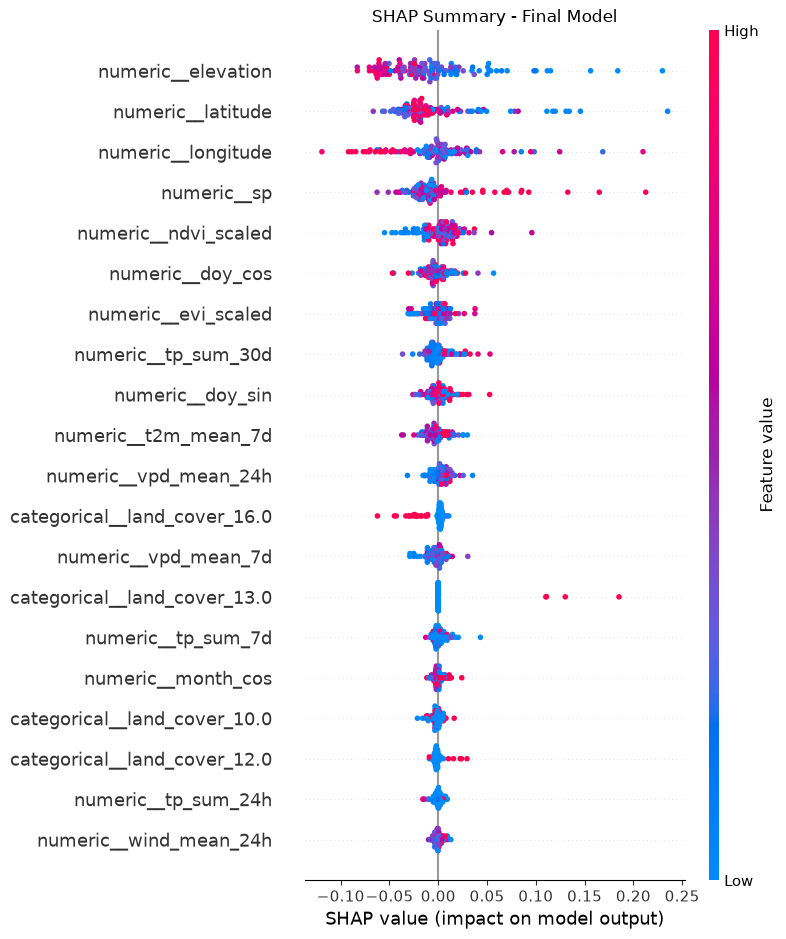

In [63]:
# SHAP summary plot for the final trained pipeline
# Explain a small test sample to keep the computation manageable.

try:
    import shap
except ImportError:
    %pip install shap
    import shap

# Sample raw test rows, then apply the exact preprocessing from final_pipeline
SHAP_BACKGROUND_SIZE = 40
SHAP_EXPLAIN_SIZE = 120

shap_background_raw = X_test.sample(
    n=min(SHAP_BACKGROUND_SIZE, len(X_test)),
    random_state=RANDOM_STATE
)

shap_explain_raw = X_test.sample(
    n=min(SHAP_EXPLAIN_SIZE, len(X_test)),
    random_state=RANDOM_STATE + 1
)

preprocessor_final = final_pipeline.named_steps["preprocessor"]
model_final = final_pipeline.named_steps["model"]

shap_background = preprocessor_final.transform(shap_background_raw)
shap_explain = preprocessor_final.transform(shap_explain_raw)

# Feature names after scaling and one-hot encoding
shap_feature_names = preprocessor_final.get_feature_names_out()

# Explain the fire-class score (class 1)
def predict_fire_score(processed_X):
    return model_final.predict_proba(processed_X)[:, 1]

# Model-agnostic SHAP explainer, compatible with the selected sklearn model
shap_explainer = shap.Explainer(
    predict_fire_score,
    masker=shap.maskers.Independent(shap_background),
    algorithm="permutation",
    feature_names=shap_feature_names
)

shap_values = shap_explainer(
    shap_explain,
    max_evals=2 * shap_explain.shape[1] + 1
)

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    features=shap_explain,
    feature_names=shap_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary - Final Model")
plt.tight_layout()
plt.show()

## 14. Save the Final Model (Deployment Preparation)

The final pipeline bundles **preprocessing + the tuned model together**, so
anything downstream (the API, the Streamlit app) can call `.predict_proba()`
directly on raw feature values, without re-implementing the scaling/encoding
logic. Alongside the model, a JSON schema is saved describing the expected
input features, the decision threshold, the probability correction and the
winsorization bounds.

**Deployment note.** The pipeline expects the columns listed under `features` in
`feature_schema.json`. Besides the raw variables this includes derived features
(relative humidity, VPD, wind direction, day-of-year, ...) and — when selected —
antecedent features that need the *recent weather history* of the cell (rain over
the last 24 h / 7 d / 30 d, ...) and the grid-cell coordinates. The API and the
Streamlit app must therefore compute or ask for exactly these inputs; the
formulas are stored in `feature_definitions`. If antecedent history is not
available in the deployed application, set `USE_HISTORY_FEATURES = False` and
re-run the notebook.

The alert decision is `predict_proba(x)[:, 1] >= decision_threshold`. The value
to display as "probability of fire" is
`odds = p/(1-p) * (natural_fire_rate/(1-natural_fire_rate)) / (training_effective_prior/(1-training_effective_prior))`,
`risk_probability = odds/(1+odds)`.

In [62]:
import joblib
import json

MODEL_PATH = "wildfire_model_pipeline.joblib"
SCHEMA_PATH = "feature_schema.json"

joblib.dump(final_pipeline, MODEL_PATH, compress=3)

land_cover_categories = (
    trainval_balanced["land_cover"].cat.categories.tolist()
    if hasattr(trainval_balanced["land_cover"], "cat")
    else sorted(trainval_balanced["land_cover"].dropna().unique().tolist())
)

all_feature_definitions = {
    "t2m_celsius": "t2m - 273.15",
    "d2m_celsius": "d2m - 273.15",
    "ndvi_scaled": "ndvi * 0.0001",
    "evi_scaled": "evi * 0.0001",
    "wind_speed": "sqrt(u10^2 + v10^2)",
    "temp_dewpoint_spread": "t2m_celsius - d2m_celsius",
    "rel_humidity": "100 * es(d2m_celsius) / es(t2m_celsius), clipped to [0, 100]",
    "vpd": "es(t2m_celsius) - es(d2m_celsius) in kPa, clipped at 0; es(T) = 0.6108 * exp(17.27 * T / (T + 237.3))",
    "month_sin": "sin(2*pi*month/12)", "month_cos": "cos(2*pi*month/12)",
    "hour_sin": "sin(2*pi*hour/24), hour in UTC", "hour_cos": "cos(2*pi*hour/24), hour in UTC",
    "doy_sin": "sin(2*pi*day_of_year/365.25)", "doy_cos": "cos(2*pi*day_of_year/365.25)",
    "wind_dir_sin": "sin(atan2(-u10, -v10))", "wind_dir_cos": "cos(atan2(-u10, -v10))",
    "tp_sum_24h": "sum of tp over the last 24 hourly steps, including the current one",
    "tp_sum_7d": "sum of tp over the last 168 hourly steps",
    "tp_sum_30d": "sum of tp over the last 720 hourly steps",
    "vpd_mean_24h": "mean of hourly VPD over the last 24 steps",
    "vpd_mean_7d": "mean of hourly VPD over the last 168 steps",
    "t2m_mean_7d": "mean of t2m in deg C over the last 168 steps",
    "wind_mean_24h": "mean of hourly wind_speed over the last 24 steps",
    "fire_prev_24h": "1 if a fire was detected in this cell during the previous 24 hours",
    "latitude": "grid-cell latitude", "longitude": "grid-cell longitude",
}

feature_schema = {
    "target": target,
    "model_name": best_model_class,
    "best_params": best_params,
    "feature_set": selected_set_name,
    "features": features_engineered,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "land_cover_categories": land_cover_categories,
    "feature_definitions": {f: all_feature_definitions[f] for f in features_engineered if f in all_feature_definitions},
    "winsorization_bounds": {k: list(v) for k, v in clip_bounds.items()},
    "decision_threshold": best_threshold,
    "threshold_strategy": THRESHOLD_STRATEGY,
    "beta": BETA,
    "probability_correction": {
        "method": "prior_shift_odds",
        "training_effective_prior": eff_prior,
        "natural_fire_rate": natural_prior,
    },
    "validation_pr_auc": best_val_pr_auc,
    "validation_f1_at_best_threshold": best_val_selection["f1"],
    "validation_fbeta_at_best_threshold": best_val_selection["fbeta"],
    "test_scores": final_test_scores,
}

with open(SCHEMA_PATH, "w") as f:
    json.dump(feature_schema, f, indent=2, default=float)

print("Saved:", MODEL_PATH)
print("Saved:", SCHEMA_PATH)

Saved: wildfire_model_pipeline.joblib
Saved: feature_schema.json


## 15. Project Checklist Status

| Step | Status |
|---|---|
| 1. Introduction | Done |
| 2. Dataset Selection and Data Sources | Done — real, ~30M-row multi-source dataset |
| 3. Loading and Inspecting the Dataset | Done — dataset loaded, dimensions/variables/target inspected |
| 4. Data Quality Analysis | Done — missing values, grid completeness, dtypes, constant/cardinality checks, class balance |
| 5. Data Cleaning, Outlier Treatment and Feature Preparation | Done — missing values, duplicates, outliers (winsorization with training-period bounds), memory optimization |
| 6. Exploratory Data Analysis (EDA) | Done — stats, distributions, correlations, class balance |
| 7. Time-Based Feature Engineering | Done — units, wind speed, dryness (spread, relative humidity, VPD), cyclical time, wind direction, antecedent history features, validation-based feature-group ablation |
| 8. Time-Based Train-Validation-Test Split | Done — chronological split with a 24-hour embargo at each boundary (no random shuffling, to avoid leakage) |
| 9. Handling Class Imbalance and Dataset Size | Done — all fire rows kept + no-fire undersampling, class weights, size caps for training/eval samples |
| 10. Data Preprocessing and Feature-Set Selection | Done — encoding, scaling, and validation-based feature-group selection |
| 11. Model Building | Done — Logistic Regression, Random Forest, HistGradientBoosting (all class-weighted) |
| 12. Model Evaluation | Done — PR-AUC, Recall/Precision, F1/F2, ROC-AUC, Accuracy, confusion matrices, calibration, permutation importance |
| 13. Model Optimization | Done — time-based validation, random search incl. `class_weight`, PR-AUC ranking, F2-optimal threshold, refit with the identical sampling recipe |
| 14. Save the Final Model (Deployment Preparation) | Model + schema saved (`wildfire_model_pipeline.joblib`, `feature_schema.json`). The API (`api_app.py`) and Streamlit demo (`streamlit_app.py`) must supply the input features listed in the schema (derived and antecedent features included) and use `decision_threshold` |

**Remaining work (outside this notebook):** write the PDF/PPT report, push the code + `requirements.txt` to GitHub, and actually deploy the API/Streamlit app (e.g. Render / Streamlit Cloud). These are packaging/writing/hosting tasks, not further modeling work.
